In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Import the main libraries used for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load the intake dataset
intakes = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Project/data/cleaned_intakes_masked.csv")

In [5]:
# Load the household member dataset
household = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Project/data/household_members_long_v2.csv"
)

## Task 0 — Understanding the Ticket Structure

Before beginning the analysis, we first examined how SLCM's Jira ticket system is organized.

The goals of this section are to understand:

- what the `NEIG-#####` ticket number represents,
- how ticket numbers relate to creation dates,
- why tickets belonging to the same PID are not necessarily consecutive,
- how `Issue Type` and `Parent key` help distinguish profile records from follow-up/service tickets,
- and how `PID` is used to identify repeat contacts.


In [14]:
# Create a copy for Task 0 so the original intake dataset is not modified
task0 = intakes.copy()

print("Task 0 dataset shape:", task0.shape)

Task 0 dataset shape: (639, 93)


In [15]:
# Display the main columns used to understand the ticket structure
ticket_columns = [
    "PID",
    "Issue key",
    "Issue id",
    "Issue Type",
    "Created",
    "Parent",
    "Parent key"
]

task0[ticket_columns].head(20)

,PID,Issue key,Issue id,Issue Type,Created,Parent,Parent key
0,P0289,NEIG-19349,60769,New Profile,12/Aug/26 11:12 AM,NaN,NaN
1,P0352,NEIG-19336,60756,New Profile,12/Aug/26 10:25 AM,NaN,NaN
2,P0308,NEIG-19324,60744,New Profile,12/Aug/26 9:24 AM,NaN,NaN
3,P0253,NEIG-19311,60731,New Profile,11/Aug/26 1:47 PM,NaN,NaN
4,P0102,NEIG-19296,60716,New Profile,11/Aug/26 11:54 AM,NaN,NaN
5,P0201,NEIG-19283,60703,New Profile,11/Aug/26 10:59 AM,NaN,NaN
6,P0037,NEIG-19273,60693,New Profile,11/Aug/26 10:15 AM,NaN,NaN
7,P0339,NEIG-19264,60684,New Profile,11/Aug/26 9:41 AM,NaN,NaN
8,P0353,NEIG-19258,60678,New Profile,11/Aug/26 8:57 AM,NaN,NaN
9,P0191,NEIG-19245,60665,New Profile,11/Aug/26 7:41 AM,NaN,NaN


In [16]:
# Extract the numeric part of the NEIG ticket number
task0["NEIG Number"] = (
    task0["Issue key"]
    .str.extract(r"(\d+)$")[0]
    .astype("Int64")
)

In [18]:
# Convert the Created column from text into datetime format
task0["Created"] = pd.to_datetime(
    task0["Created"],
    format="%d/%b/%y %I:%M %p",
    errors="coerce"
)

In [19]:
# Compare the oldest and newest tickets to see how NEIG numbers change over time
print("Oldest tickets:")

display(
    task0[
        ["Issue key", "NEIG Number", "Issue id", "Created"]
    ]
    .sort_values("Created")
    .head(10)
)

print("\nNewest tickets:")

display(
    task0[
        ["Issue key", "NEIG Number", "Issue id", "Created"]
    ]
    .sort_values("Created")
    .tail(10)
)

Oldest tickets:


,Issue key,NEIG Number,Issue id,Created
638,NEIG-10695,10695,35312,2026-01-01 09:15:00
637,NEIG-10735,10735,35478,2026-01-05 13:53:00
636,NEIG-10748,10748,35500,2026-01-06 01:02:00
635,NEIG-10753,10753,35509,2026-01-06 01:44:00
634,NEIG-10757,10757,35548,2026-01-06 11:35:00
633,NEIG-10761,10761,35555,2026-01-06 12:26:00
632,NEIG-10769,10769,35602,2026-01-06 18:24:00
631,NEIG-10775,10775,35613,2026-01-06 20:25:00
630,NEIG-10811,10811,35711,2026-01-07 13:43:00
629,NEIG-10816,10816,35720,2026-01-07 15:08:00



Newest tickets:


,Issue key,NEIG Number,Issue id,Created
9,NEIG-19245,19245,60665,2026-08-11 07:41:00
8,NEIG-19258,19258,60678,2026-08-11 08:57:00
7,NEIG-19264,19264,60684,2026-08-11 09:41:00
6,NEIG-19273,19273,60693,2026-08-11 10:15:00
5,NEIG-19283,19283,60703,2026-08-11 10:59:00
4,NEIG-19296,19296,60716,2026-08-11 11:54:00
3,NEIG-19311,19311,60731,2026-08-11 13:47:00
2,NEIG-19324,19324,60744,2026-08-12 09:24:00
1,NEIG-19336,19336,60756,2026-08-12 10:25:00
0,NEIG-19349,19349,60769,2026-08-12 11:12:00


### Ticket Number Observation

The `NEIG-#####` value represents an individual Jira ticket rather than a person or household.

The oldest tickets in the dataset have lower NEIG numbers, while the newest tickets have higher NEIG numbers. `Issue id` follows the same general progression.

This shows that ticket numbers are assigned as tickets are created across the SLCM system.

In [20]:
# Count how many tickets are associated with each PID
pid_counts = task0["PID"].value_counts()

print("Total ticket records:", len(task0))
print("Unique PIDs:", task0["PID"].nunique())
print("PIDs with more than one ticket:", (pid_counts > 1).sum())

Total ticket records: 639
Unique PIDs: 439
PIDs with more than one ticket: 150


In [21]:
# Select one PID that appears on multiple tickets
repeat_pids = pid_counts[pid_counts > 1]

example_pid = repeat_pids.index[0]

task0[
    task0["PID"] == example_pid
][
    [
        "PID",
        "Issue key",
        "NEIG Number",
        "Issue Type",
        "Created",
        "Parent key"
    ]
].sort_values("Created")

,PID,Issue key,NEIG Number,Issue Type,Created,Parent key
500,P0101,NEIG-12683,12683,New Profile,2026-03-09 11:35:00,NaN
482,P0101,NEIG-13006,13006,Rent Assistance Care Path,2026-03-20 08:38:00,NEIG-12683
424,P0101,NEIG-13824,13824,New Profile,2026-04-14 10:34:00,NaN
404,P0101,NEIG-14015,14015,Rent Assistance Care Path,2026-04-17 13:05:00,NEIG-13824
354,P0101,NEIG-14662,14662,New Profile,2026-05-07 14:28:00,NaN
172,P0101,NEIG-16993,16993,New Profile,2026-07-03 15:32:00,NaN


### Repeat PID Observation

The same PID can have multiple tickets created at different times.

For example, PID `P0101` appears on several non-consecutive tickets, including `NEIG-12683`, `NEIG-13824`, `NEIG-14662`, and `NEIG-16993`.

This shows that:

- `PID` identifies the same person/family across multiple contacts.
- `Issue key` identifies an individual Jira ticket.
- Ticket numbers are not sequential within a family because they are assigned across all SLCM cases.
- Some service tickets, such as `Rent Assistance Care Path`, are linked to a profile ticket using `Parent key`.
- A PID can also have more than one `New Profile` ticket over time.

In [22]:
# Count the different Issue Types in the dataset
task0["Issue Type"].value_counts()

,count
Issue Type,
New Profile,378
Rent Assistance Care Path,112
Connected Neighbor Profile,44
House Navigation Care Path,24
Basic Supplies,17
Utility Care Path,12
Other,9
Legal Assistance Care Path,7
Food Care Path,5


In [23]:
# Create an indicator showing whether each ticket has a parent ticket
task0["Has Parent"] = task0["Parent key"].notna()

task0["Has Parent"].value_counts()

,count
Has Parent,
False,426
True,213


In [24]:
# Compare Issue Type with whether the ticket has a parent
issue_parent_table = pd.crosstab(
    task0["Issue Type"],
    task0["Has Parent"]
)

issue_parent_table

Has Parent,False,True
Issue Type,,
Basic Supplies,0,17
Care Plan,0,1
Case Management Navigation Path,0,1
Child Care Path,0,2
Children's Welfare (CPS),0,1
Connected Neighbor Profile,44,0
Digital Access,0,3
Eviction Prevention Care Path,0,3
Flourishing Neighbor Profile,4,0


### Issue Type and Parent Ticket Observation

The relationship between `Issue Type` and `Parent key` clearly separates profile records from service or care-path tickets.

There are 426 profile records:

- 378 `New Profile`
- 44 `Connected Neighbor Profile`
- 4 `Flourishing Neighbor Profile`

None of these profile records have a `Parent key`.

The remaining 213 records are service or care-path tickets, such as:

- `Rent Assistance Care Path`
- `House Navigation Care Path`
- `Utility Care Path`
- `Legal Assistance Care Path`
- `Basic Supplies`

All of these records have a `Parent key`, linking them back to a profile-level ticket.

This shows that `Issue Type` and `Parent key` should be used together to distinguish main profile records from follow-up or service sub-tickets.

In [25]:
# Summarize profile records versus service/sub-ticket records
profile_types = [
    "New Profile",
    "Connected Neighbor Profile",
    "Flourishing Neighbor Profile"
]

profile_count = task0[
    task0["Issue Type"].isin(profile_types)
].shape[0]

service_count = task0[
    ~task0["Issue Type"].isin(profile_types)
].shape[0]

print("Profile records:", profile_count)
print("Service / care-path records:", service_count)
print("Total records:", profile_count + service_count)

Profile records: 426
Service / care-path records: 213
Total records: 639


### Task 0 Conclusion

The SLCM intake dataset is organized around Jira tickets rather than one row per unique person or household.

- `Issue key` (`NEIG-#####`) identifies an individual Jira ticket.
- Higher NEIG numbers generally correspond to tickets created later in time.
- `PID` links multiple tickets belonging to the same person/family.
- Ticket numbers are not sequential within a family because tickets are created across the entire SLCM system.
- Profile records (`New Profile`, `Connected Neighbor Profile`, and `Flourishing Neighbor Profile`) do not have a parent ticket.
- Service and care-path records are linked to a profile ticket through `Parent key`.
- `Issue Type` and `Parent key` together distinguish profile-level records from follow-up/service sub-tickets.

## Task 1 — Map the Data to the Partner Plan

The goal of this section is to use the real SLCM data to compare the dataset with the partner's Reconnect / Rethink / Rebuild framework.

We will:

1. Calculate the values needed for Figure 1.
2. Calculate the four groups needed for Figure 2.
3. Classify all 93 columns as Needed, Optional, or Drop.
4. Identify which parts of the partner plan are not directly supported by the available data.

In [26]:
# Create a separate copy for Task 1 so the original dataset remains unchanged
task1 = intakes.copy()

print("Task 1 copy shape:", task1.shape)

Task 1 copy shape: (639, 93)


In [27]:
# Review the Issue Types that may correspond to different parts of the partner plan
task1["Issue Type"].value_counts()

,count
Issue Type,
New Profile,378
Rent Assistance Care Path,112
Connected Neighbor Profile,44
House Navigation Care Path,24
Basic Supplies,17
Utility Care Path,12
Other,9
Legal Assistance Care Path,7
Food Care Path,5


In [28]:
# Review the available Housing Status categories
task1["Custom field (Housing Status)"].value_counts(dropna=False)

,count
Custom field (Housing Status),
Rent- past due,234
NaN,213
Rent - nothing past due,126
Staying with friends/family,29
Unhoused,15
Other,10
Own home - nothing past due,5
Own home - mortgage past due,4
Staying at extended stay hotel or short-term housing,3


In [29]:
# Review the available Eviction Status categories
task1["Custom field (Eviction Status)"].value_counts(dropna=False)

,count
Custom field (Eviction Status),
Not being evicted,255
NaN,213
Currently being evicted,106
Unknown,63
Received 7 day notice,2


In [36]:
# Define the Housing Status values used for stable and at-risk groups
stable_statuses = [
    "Rent - nothing past due",
    "Own home - nothing past due"
]

risk_housing_statuses = [
    "Rent- past due",
    "Own home - mortgage past due",
    "Staying with friends/family",
    "Unhoused",
    "Staying at extended stay hotel or short-term housing"
]

risk_eviction_statuses = [
    "Currently being evicted",
    "Received 7 day notice"
]

In [37]:
# Classify Reconnect records using both Housing Status and Eviction Status
reconnect["Housing Group"] = "Unclear"

risk_mask = (
    reconnect["Custom field (Housing Status)"].isin(risk_housing_statuses)
    |
    reconnect["Custom field (Eviction Status)"].isin(risk_eviction_statuses)
)

stable_mask = (
    reconnect["Custom field (Housing Status)"].isin(stable_statuses)
    &
    ~risk_mask
)

reconnect.loc[
    risk_mask,
    "Housing Group"
] = "Eviction / housing risk"

reconnect.loc[
    stable_mask,
    "Housing Group"
] = "Housing stable"

In [38]:
# Display the final Figure 1 counts
figure1_counts = reconnect["Housing Group"].value_counts()

print("Reconnect / Profile tickets:", len(reconnect))
print()
print(figure1_counts)

Reconnect / Profile tickets: 426

Housing Group
Eviction / housing risk    291
Housing stable             126
Unclear                      9
Name: count, dtype: int64


In [39]:
# Calculate the percentage of Reconnect records in each housing group
figure1_percent = (
    reconnect["Housing Group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

figure1_percent

,proportion
Housing Group,
Eviction / housing risk,68.3
Housing stable,29.6
Unclear,2.1


In [40]:
# Display the records that were classified as Unclear
unclear_entries = reconnect[
    reconnect["Housing Group"] == "Unclear"
]

unclear_entries[
    [
        "PID",
        "Issue key",
        "Issue Type",
        "Custom field (Housing Status)",
        "Custom field (Eviction Status)"
    ]
]

,PID,Issue key,Issue Type,Custom field (Housing Status),Custom field (Eviction Status)
0,P0289,NEIG-19349,New Profile,Other,Not being evicted
45,P0075,NEIG-18871,New Profile,Other,Not being evicted
96,P0294,NEIG-18273,New Profile,Other,Not being evicted
248,P0336,NEIG-16171,New Profile,Other,Not being evicted
250,P0006,NEIG-16162,New Profile,Other,Not being evicted
259,P0051,NEIG-15996,New Profile,Other,Not being evicted
267,P0384,NEIG-15860,New Profile,Other,Not being evicted
314,P0143,NEIG-15222,New Profile,Other,Not being evicted
366,P0024,NEIG-14552,New Profile,Other,Not being evicted


In [41]:
# Reclassify Unclear records that are explicitly marked as not being evicted
reconnect.loc[
    (reconnect["Housing Group"] == "Unclear") &
    (reconnect["Custom field (Eviction Status)"] == "Not being evicted"),
    "Housing Group"
] = "Housing stable"

In [42]:
# Display the updated Figure 1 housing groups
reconnect["Housing Group"].value_counts()

,count
Housing Group,
Eviction / housing risk,291
Housing stable,135


### Figure 1 Results

We identified 426 profile-level tickets and used them as a proxy for the Reconnect stage.

For the Figure 1 split, records were classified using both
`Custom field (Housing Status)` and `Custom field (Eviction Status)`.

A record was classified as **Eviction / housing risk** if its housing status
showed past-due rent/mortgage, staying with friends/family, unhoused, or
short-term housing, or if its eviction status was `Currently being evicted`
or `Received 7 day notice`.

The initial classification produced 9 records with Housing Status = `Other`,
so these records could not be classified using Housing Status alone.

We inspected their `Custom field (Eviction Status)` values and found that all
9 were explicitly recorded as `Not being evicted`.

Because Figure 1 requires a two-way split between housing stable and eviction
risk, these 9 records were moved to the **Housing stable / not currently at
eviction risk** group. This does not necessarily mean that their housing
situation is completely stable, but the available data indicates that they
were not currently at eviction risk.

All remaining records were classified as **Housing stable / not currently at
eviction risk**. This includes records with Housing Status = `Other` when
Eviction Status = `Not being evicted`.

Final counts:

- **Eviction / housing risk:** 291
- **Housing stable / not currently at eviction risk:** 135
- **Total Reconnect/profile tickets:** 426

This grouping was created from the available housing and eviction fields and
is not a classification directly recorded by SLCM.

## Figure 2 — Urgency / Duration Segmentation

Figure 2 groups people using `PID` rather than individual tickets.

The assignment defines the groups as follows:

- **Episodic:** PID appears on exactly 1 ticket
- **Chronic:** PID appears on 2 or more tickets
- **Urgent:** the person's housing information shows that they are `Currently being evicted` or `Unhoused`
- **Less urgent:** the person does not meet the urgent definition

Because a PID can appear on multiple profile records over time, we use the most recent profile record for each PID when determining the person's current housing and eviction status.

In [43]:
# Count how many tickets are associated with each PID
pid_ticket_counts = (
    task1["PID"]
    .value_counts()
    .reset_index()
)

pid_ticket_counts.columns = ["PID", "Ticket Count"]

pid_ticket_counts.head()

,PID,Ticket Count
0,P0101,6
1,P0286,4
2,P0027,4
3,P0256,4
4,P0302,4


In [44]:
# Classify each PID based on the number of tickets
pid_ticket_counts["Duration Group"] = np.where(
    pid_ticket_counts["Ticket Count"] == 1,
    "Episodic",
    "Chronic"
)

pid_ticket_counts["Duration Group"].value_counts()

,count
Duration Group,
Episodic,289
Chronic,150


In [46]:
# Keep only profile-level records for the Figure 2 housing classification
figure2_profiles = task1[
    task1["Issue Type"].isin([
        "New Profile",
        "Connected Neighbor Profile",
        "Flourishing Neighbor Profile"
    ])
].copy()

print("Profile records:", len(figure2_profiles))

Profile records: 426


In [48]:
# Convert Created to datetime so the most recent profile can be identified
figure2_profiles["Created"] = pd.to_datetime(
    figure2_profiles["Created"],
    format="%d/%b/%y %I:%M %p",
    errors="coerce"
)

In [49]:
# Keep the most recent profile record for each PID
latest_profiles = (
    figure2_profiles
    .sort_values("Created")
    .drop_duplicates(subset="PID", keep="last")
)

print("Unique PIDs with profile records:", len(latest_profiles))

Unique PIDs with profile records: 395


In [50]:
# Display the fields that will be used to determine urgency
latest_profiles[
    [
        "PID",
        "Created",
        "Custom field (Housing Status)",
        "Custom field (Eviction Status)"
    ]
].head()

,PID,Created,Custom field (Housing Status),Custom field (Eviction Status)
638,P0337,2026-01-01 09:15:00,Rent- past due,Unknown
637,P0230,2026-01-05 13:53:00,Rent - nothing past due,Not being evicted
636,P0114,2026-01-06 01:02:00,Rent- past due,Currently being evicted
634,P0183,2026-01-06 11:35:00,Rent- past due,Unknown
633,P0369,2026-01-06 12:26:00,Rent- past due,Currently being evicted


In [51]:
# Classify each PID as Urgent or Less urgent using the Figure 2 definition
urgent_mask = (
    (latest_profiles["Custom field (Eviction Status)"] == "Currently being evicted")
    |
    (latest_profiles["Custom field (Housing Status)"] == "Unhoused")
)

latest_profiles["Urgency Group"] = np.where(
    urgent_mask,
    "Urgent",
    "Less urgent"
)

latest_profiles["Urgency Group"].value_counts()

,count
Urgency Group,
Less urgent,282
Urgent,113


In [52]:
# Merge the ticket-frequency classification with the most recent housing classification
figure2 = latest_profiles.merge(
    pid_ticket_counts,
    on="PID",
    how="left"
)

figure2[
    ["PID", "Ticket Count", "Duration Group", "Urgency Group"]
].head()

,PID,Ticket Count,Duration Group,Urgency Group
0,P0337,1,Episodic,Less urgent
1,P0230,2,Chronic,Less urgent
2,P0114,1,Episodic,Urgent
3,P0183,2,Chronic,Less urgent
4,P0369,1,Episodic,Urgent


In [53]:
# Count the PIDs in each Figure 2 quadrant
figure2_counts = pd.crosstab(
    figure2["Duration Group"],
    figure2["Urgency Group"]
)

figure2_counts

Urgency Group,Less urgent,Urgent
Duration Group,,
Chronic,126,24
Episodic,156,89


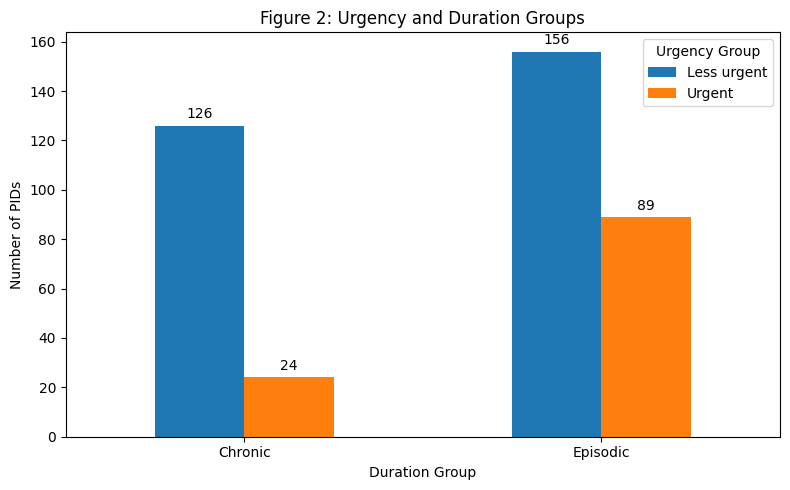

In [54]:
# Plot the Figure 2 PID groups as a grouped bar chart with labels
ax = figure2_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Figure 2: Urgency and Duration Groups")
plt.xlabel("Duration Group")
plt.ylabel("Number of PIDs")
plt.xticks(rotation=0)
plt.legend(title="Urgency Group")

# Add count labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

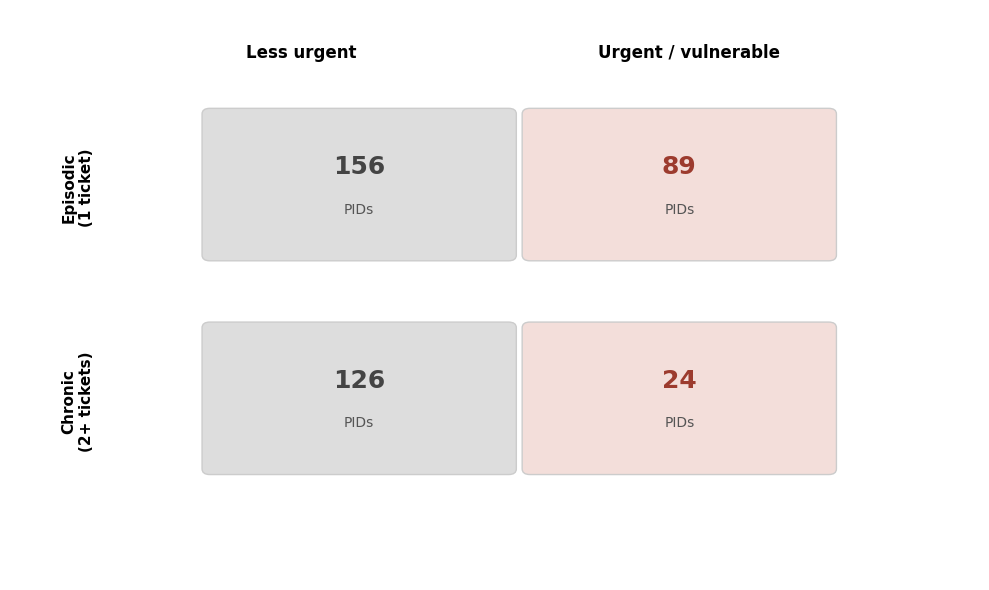

In [55]:
# Create a Figure 2 diagram styled like the assignment template
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Extract the four values from the figure2_counts table
episodic_less = figure2_counts.loc["Episodic", "Less urgent"]
episodic_urgent = figure2_counts.loc["Episodic", "Urgent"]
chronic_less = figure2_counts.loc["Chronic", "Less urgent"]
chronic_urgent = figure2_counts.loc["Chronic", "Urgent"]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")

# Title labels
ax.text(3, 7.4, "Less urgent", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(7, 7.4, "Urgent / vulnerable", ha="center", va="center", fontsize=12, fontweight="bold")

# Side labels
ax.text(0.7, 5.5, "Episodic\n(1 ticket)", ha="center", va="center",
        fontsize=11, fontweight="bold", rotation=90)
ax.text(0.7, 2.5, "Chronic\n(2+ tickets)", ha="center", va="center",
        fontsize=11, fontweight="bold", rotation=90)

# Box styles
box_width = 3.2
box_height = 2.1

# Colors similar to the template
less_color = "#dddddd"
urgent_color = "#f3deda"

# Draw the 4 boxes
boxes = [
    (2.0, 4.5, less_color, episodic_less),
    (5.3, 4.5, urgent_color, episodic_urgent),
    (2.0, 1.5, less_color, chronic_less),
    (5.3, 1.5, urgent_color, chronic_urgent),
]

for x, y, color, value in boxes:
    rect = FancyBboxPatch(
        (x, y), box_width, box_height,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1,
        facecolor=color,
        edgecolor="#cccccc"
    )
    ax.add_patch(rect)

    # Main number
    ax.text(
        x + box_width / 2,
        y + box_height / 2 + 0.25,
        f"{value}",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="#9c3b2e" if color == urgent_color else "#444444"
    )

    # Subtitle
    ax.text(
        x + box_width / 2,
        y + box_height / 2 - 0.35,
        "PIDs",
        ha="center",
        va="center",
        fontsize=10,
        color="#555555"
    )

plt.tight_layout()
plt.show()

### Figure 2 Results

Figure 2 groups individuals using `PID` based on the frequency of their contact with SLCM and the urgency of their most recent housing situation.

To determine **duration**:

- **Episodic** = the PID appears on exactly 1 ticket.
- **Chronic** = the PID appears on 2 or more tickets.

To determine **urgency**, we used the most recent profile-level record for each PID and examined:

- `Custom field (Housing Status)`
- `Custom field (Eviction Status)`

A PID was classified as **Urgent / vulnerable** if the most recent profile showed either:

- Housing Status = `Unhoused`, or
- Eviction Status = `Currently being evicted`.

All other PIDs were classified as **Less urgent**.

The most recent profile was used because some PIDs appear multiple times and their housing or eviction situation may change between contacts.

The final four groups were:

- **Episodic + Less urgent:** 156
- **Episodic + Urgent / vulnerable:** 89
- **Chronic + Less urgent:** 126
- **Chronic + Urgent / vulnerable:** 24

These categories are proxies created from the available data. SLCM does not directly record a field called `Episodic`, `Chronic`, or `Urgent`.

In [56]:
# Find PIDs that appear in the full dataset but not in the profile-level records
all_pids = set(task1["PID"].dropna().unique())
profile_pids = set(figure2_profiles["PID"].dropna().unique())

service_only_pids = all_pids - profile_pids

print("Unique PIDs in full dataset:", len(all_pids))
print("Unique PIDs in profile records:", len(profile_pids))
print("PIDs without a profile record:", len(service_only_pids))

Unique PIDs in full dataset: 439
Unique PIDs in profile records: 395
PIDs without a profile record: 44


In [57]:
# Inspect the ticket types associated with PIDs that have no profile-level record
task1[
    task1["PID"].isin(service_only_pids)
][
    ["PID", "Issue key", "Issue Type", "Parent key"]
].sort_values(["PID", "Issue key"])

,PID,Issue key,Issue Type,Parent key
392,P0330,NEIG-14160,Care Plan,NEIG-11044
48,P0397,NEIG-18848,Rent Assistance Care Path,NEIG-17497
62,P0398,NEIG-18768,Rent Assistance Care Path,NEIG-16897
154,P0399,NEIG-17104,Basic Supplies,NEIG-15860
155,P0400,NEIG-17103,Basic Supplies,NEIG-15860
156,P0401,NEIG-17102,Rent Assistance Care Path,NEIG-15860
194,P0402,NEIG-16861,Rent Assistance Care Path,NEIG-16162
298,P0403,NEIG-15295,House Navigation Care Path,NEIG-15051
299,P0404,NEIG-15294,Utility Care Path,NEIG-15051
303,P0405,NEIG-15267,Rent Assistance Care Path,NEIG-15064


#### Figure 2 Data Limitation

The full dataset contains 439 unique PIDs. However, only 395 PIDs have at least one profile-level record containing the housing and eviction information needed to determine urgency.

The remaining 44 PIDs appear only on service or care-path tickets. These records have a `Parent key`, but they do not contain their own Housing Status or Eviction Status values.

Because the Figure 2 urgency definition requires either `Custom field (Housing Status)` or `Custom field (Eviction Status)`, these 44 PIDs could not be reliably classified as Urgent or Less urgent.

Therefore, Figure 2 contains 395 classifiable PIDs:

- Episodic + Less urgent: 156
- Episodic + Urgent: 89
- Chronic + Less urgent: 126
- Chronic + Urgent: 24

An additional 44 PIDs were excluded from the urgency quadrants because the required housing information was unavailable.

## Task 1C — Column Triage

Each of the 93 columns in the intake dataset was classified as:

- **Needed** — directly supports the required questions or is important for the housing, financial, demographic, geographic, or repeat-contact analysis.
- **Optional** — could provide useful supporting context but is not required for the main analysis.
- **Drop** — mainly contains Jira administrative information, redundant information, or fields that are not needed for Part 1.


In [58]:
# Create the 93-column triage DataFrame for Task 1
triage_data = [
    ["PID", "Needed", "Identifies the same person/family across multiple tickets and is required for repeat-contact analysis."],
    ["PID Match Basis", "Optional", "Helps evaluate how reliably records were matched to the same PID."],
    ["Summary", "Drop", "Mostly descriptive ticket text and is not required for the quantitative analysis."],
    ["Issue key", "Needed", "Identifies each individual Jira ticket and supports ticket and parent-ticket analysis."],
    ["Issue id", "Drop", "Internal Jira identifier; Issue key already identifies the ticket."],
    ["Issue Type", "Needed", "Distinguishes profile-level tickets from service/care-path sub-tickets."],
    ["Status", "Drop", "Jira workflow status rather than information about the household's situation."],
    ["Resolution", "Drop", "Jira workflow outcome that is not required for the main analysis."],
    ["Reporter", "Drop", "Identifies staff rather than describing the household."],
    ["Reporter Id", "Drop", "Internal staff identifier."],
    ["Creator", "Drop", "Identifies the staff member who created the ticket rather than the household."],
    ["Creator Id", "Drop", "Internal staff identifier."],
    ["Created", "Needed", "Required to order tickets over time and identify first and most recent contacts."],
    ["Updated", "Optional", "Shows when the ticket was last modified and could help examine how long cases remain active."],
    ["Resolved", "Optional", "Shows when a ticket was resolved and could support analysis of case duration."],
    ["Labels.1", "Drop", "Jira tagging field that is not needed for the required analysis."],
    ["Labels.2", "Drop", "Jira tagging field that is not needed for the required analysis."],
    ["Labels.3", "Drop", "Jira tagging field that is not needed for the required analysis."],
    ["Labels.4", "Drop", "Jira tagging field that is not needed for the required analysis."],
    ["Labels.5", "Drop", "Jira tagging field that is not needed for the required analysis."],
    ["Labels.6", "Drop", "Jira tagging field that is not needed for the required analysis."],
    ["Watchers", "Drop", "Staff/workflow information rather than household information."],
    ["Watchers.1", "Drop", "Additional staff/workflow information that is not needed."],
    ["Watchers Id", "Drop", "Internal Jira identifier."],
    ["Watchers Id.1", "Drop", "Internal Jira identifier."],
    ["# Additional Household Members", "Needed", "Directly supports household-size and household-composition analysis."],
    ["Custom field (City)", "Optional", "Provides additional geographic context and can be compared with ZIP Code."],
    ["Custom field (Community Ministry)", "Optional", "Could be used to compare cases across different community ministry service areas."],
    ["Custom field (Court Date)", "Optional", "Could provide additional information about the severity and timing of eviction cases."],
    ["Custom field (Current Employer)", "Drop", "Employer name is not necessary; Employment Status is sufficient for the main analysis."],
    ["Age at Intake", "Needed", "Core demographic variable for describing the population served."],
    ["Custom field (Employment Status)", "Needed", "Directly required for the employment-versus-income analysis."],
    ["Custom field (Eviction Reason)", "Needed", "Helps explain why households are experiencing eviction or housing instability."],
    ["Custom field (Eviction Status)", "Needed", "Required for Figures 1-2 and the housing-crisis analysis."],
    ["Custom field (Gender)", "Needed", "Core demographic variable for describing the population."],
    ["Custom field (Goals)", "Drop", "Qualitative goal information that is not required for the main quantitative analysis."],
    ["Custom field (Goals).1", "Drop", "Additional qualitative goal information that is not required."],
    ["Custom field (Goals).2", "Drop", "Additional qualitative goal information that is not required."],
    ["Custom field (Goals).3", "Drop", "Additional qualitative goal information that is not required."],
    ["Custom field (Household Identities)", "Optional", "May provide useful demographic or household context but is not central to the required questions."],
    ["Custom field (Household Identities).1", "Optional", "Provides additional household-identity information that may support descriptive analysis."],
    ["Custom field (Household repairs required?)", "Optional", "Could provide useful information about housing quality and instability."],
    ["Custom field (Housing Status)", "Needed", "Central variable for housing stability, urgency, and Figures 1-2."],
    ["Custom field (Income Amount ($))", "Needed", "Directly required for the employment-versus-income analysis."],
    ["Custom field (Insurance Provider for Family)", "Optional", "Could be simplified into insured versus uninsured and used to examine healthcare coverage."],
    ["Custom field (Intake Date)", "Optional", "Can be compared with Created, although Created is sufficient for the main time-based analysis."],
    ["Has LG&E Account on File", "Drop", "Administrative utility-account information rather than a direct measure of hardship."],
    ["Custom field (Landlord Name)", "Drop", "Specific landlord information is not needed for population-level analysis."],
    ["Custom field (Loss of Income Causation)", "Optional", "Could help explain why households experienced reduced income or financial hardship."],
    ["Custom field (Loss of Income Causation).1", "Optional", "Captures an additional reason for loss of income when more than one cause is recorded."],
    ["Custom field (Loss of Income Causation).2", "Optional", "Provides additional information about causes of income loss."],
    ["Custom field (Loss of Income Causation).3", "Optional", "Provides additional information about causes of income loss."],
    ["Custom field (Main reason Neighbor stopped paying rent)", "Needed", "Helps explain the causes behind rent delinquency and housing instability."],
    ["Custom field (Monthly Rent ($))", "Needed", "Important measure of housing cost and useful for analyzing housing burden."],
    ["Has Email on File", "Drop", "Contact-administration information that is not relevant to the required EDA."],
    ["Has Phone on File", "Drop", "Contact-administration information that is not relevant to the required EDA."],
    ["Custom field (Other Professionals Detail)", "Drop", "Unstructured case information that is not required for the main analysis."],
    ["Custom field (Other professionals helping with goals?)", "Drop", "Support-network information that is not required for the five main questions."],
    ["Custom field (Past Due Rent ($))", "Needed", "Measures the severity of rent and housing hardship."],
    ["Custom field (People in Household 17 and Under)", "Needed", "Required for understanding children and household composition."],
    ["Custom field (People in Household 18+)", "Needed", "Required for understanding adult household composition and household size."],
    ["Custom field (People in Household 65+)", "Needed", "Adds important demographic information about household composition."],
    ["Custom field (Preferred method of contact)", "Drop", "Contact preference is not relevant to the main population analysis."],
    ["Custom field (Preferred method of contact).1", "Drop", "Additional contact preference information that is not required."],
    ["Custom field (Primary Insurance)", "Drop", "Duplicates insurance-related information and is not required for the main analysis."],
    ["Custom field (Primary Language Spoken in Home)", "Needed", "Relevant demographic and access characteristic of the households served."],
    ["Custom field (Pronoun)", "Optional", "Provides additional demographic information but is not central to the required analysis."],
    ["Custom field (Race/Ethnicity)", "Needed", "Core demographic variable for describing the population served."],
    ["Custom field (Rank)", "Drop", "Jira board-ordering field rather than household information."],
    ["Custom field (Rent Intake Form Goals)", "Drop", "Qualitative rental-assistance goal information that is not needed for the main quantitative analysis."],
    ["Custom field (Rent Intake Form Goals).1", "Drop", "Additional rental-goal information that is not required."],
    ["Custom field (Rent Intake Form Goals).2", "Drop", "Additional rental-goal information that is not required."],
    ["Custom field (Rent Intake Form Goals).3", "Drop", "Additional rental-goal information that is not required."],
    ["Custom field (Rent-to-Income %)", "Needed", "Direct measure of housing affordability and financial burden."],
    ["Custom field (Response Method)", "Drop", "Program/workflow information rather than household-condition information."],
    ["Custom field (Response Method).1", "Drop", "Additional program/workflow information that is not needed."],
    ["Custom field (Section 8 or Housing Voucher)", "Needed", "Relevant housing-support variable that may relate to housing stability and affordability."],
    ["Custom field (Source of income)", "Needed", "Directly required for the employment-versus-income analysis."],
    ["Custom field (Source of income).1", "Needed", "Captures additional income sources and should be considered with the primary source."],
    ["Custom field (State)", "Optional", "Provides broader geographic information and can help validate or supplement City and ZIP Code."],
    ["Custom field (Utility Past Due)", "Optional", "Could provide additional evidence of financial hardship beyond rent."],
    ["Has Water Account on File", "Drop", "Administrative utility-account information rather than a direct measure of hardship."],
    ["Custom field (Zip Code)", "Needed", "Explicitly required for comparing housing crisis severity across ZIP codes."],
    ["Custom field ([CHART] Date of First Response)", "Drop", "Jira response-time metric that is not relevant to the required population analysis."],
    ["Custom field ([CHART] Time in Status)", "Drop", "Jira workflow metric rather than household information."],
    ["Comment", "Drop", "Unstructured text that is not required for the main quantitative analysis."],
    ["Comment.1", "Drop", "Additional unstructured text that is not required."],
    ["Comment.2", "Drop", "Additional unstructured text that is not required."],
    ["Parent", "Drop", "Parent key already provides the parent-ticket relationship more directly."],
    ["Parent key", "Needed", "Required to identify service/care-path tickets linked to parent profile tickets."],
    ["Parent summary", "Drop", "Duplicates information about the parent ticket and is not required once Parent key is retained."],
    ["Status Category", "Drop", "Jira workflow grouping rather than household-condition information."],
    ["Status Category Changed", "Drop", "Jira workflow information that is not needed for the main EDA."]
]

triage_df = pd.DataFrame(
    triage_data,
    columns=["Column", "Classification", "Reason"]
)

triage_df

,Column,Classification,Reason
0,PID,Needed,Identifies the same person/family across multi...
1,PID Match Basis,Optional,Helps evaluate how reliably records were match...
2,Summary,Drop,Mostly descriptive ticket text and is not requ...
3,Issue key,Needed,Identifies each individual Jira ticket and sup...
4,Issue id,Drop,Internal Jira identifier; Issue key already id...
...,...,...,...
88,Parent,Drop,Parent key already provides the parent-ticket ...
89,Parent key,Needed,Required to identify service/care-path tickets...
90,Parent summary,Drop,Duplicates information about the parent ticket...
91,Status Category,Drop,Jira workflow grouping rather than household-c...


In [59]:
# Verify the number of columns and the triage classifications
print("Columns in original dataset:", len(intakes.columns))
print("Columns in triage table:", len(triage_df))

print("\nTriage counts:")
print(triage_df["Classification"].value_counts())

Columns in original dataset: 93
Columns in triage table: 93

Triage counts:
Classification
Drop        49
Needed      26
Optional    18
Name: count, dtype: int64


In [60]:
# Check that every dataset column appears exactly once in the triage table
dataset_columns = set(intakes.columns)
triage_columns = set(triage_df["Column"])

print("Missing from triage:", dataset_columns - triage_columns)
print("Not found in dataset:", triage_columns - dataset_columns)

Missing from triage: set()
Not found in dataset: set()


## Task 1D — Parts of the Partner Plan Not Fully Supported by the Data

The current dataset supports some parts of SLCM's partner model, but several elements cannot be identified directly.

### Reconnect
There is no field explicitly called `Reconnect`. We used profile-level tickets (`New Profile`, `Connected Neighbor Profile`, and `Flourishing Neighbor Profile`) as a proxy for the Reconnect stage because these records represent the main intake/profile records.

### Rethink
There is no field identifying whether a household entered the Rethink stage or participated in a 3–6 month program. The dataset also does not show which Rethink program was used, when it started, or whether it was completed.

### Rebuild
There is no field showing whether a household entered the Rebuild stage or achieved long-term stability.

### Urgency
Urgency is not directly recorded. For Figure 2, we created a proxy using `Custom field (Housing Status)` and `Custom field (Eviction Status)`. A PID was considered urgent when its most recent profile showed `Unhoused` or `Currently being evicted`.

### Episodic vs. Chronic
These categories are also not directly recorded. We classified a PID with 1 ticket as Episodic and a PID with 2 or more tickets as Chronic.

### Movement Between Stages
There is no field showing when a household moves from Reconnect to Rethink or from Rethink to Rebuild.

### Long-Term Outcomes
The dataset does not consistently record follow-up outcomes several months after services, making it difficult to determine whether housing, income, employment, or overall stability improved over time.

### PID Limitation
PID allows repeat contacts to be linked, but it is based on name matching and is not perfectly reliable.

### Fields SLCM Could Add

SLCM could improve future tracking by collecting fields such as:

- Program Stage
- Stage Entry Date
- Stage Exit Date
- Rethink Program Type
- Urgency Level
- Reason for Stage Transition
- Program Completion Status
- Housing Status at Follow-up
- Employment Status at Follow-up
- Income at Follow-up
- 3-Month Follow-up Outcome
- 6-Month Follow-up Outcome
- 12-Month Follow-up Outcome
- Long-Term Stability Outcome

# Task 2 — Explore, Clean, and Answer

In Task 2, we explore both datasets, identify data-quality issues, clean the variables needed for analysis, create visualizations, and answer the five required questions.

The process is:

1. Summarize both datasets.
2. Review the variables kept from the Task 1 triage.
3. Identify missing values, unusual values, outliers, and inconsistencies.
4. Clean the data and document each decision.
5. Create plots that reveal meaningful patterns.
6. Answer the five required questions with supporting analysis.

In [61]:
# Create separate working copies for Task 2
task2_intakes = intakes.copy()
task2_household = household.copy()

print("Intake copy:", task2_intakes.shape)
print("Household copy:", task2_household.shape)

Intake copy: (639, 93)
Household copy: (993, 8)


## Task 2A — Dataset Summary

Before cleaning or analyzing the data, we first summarize the size, structure, and data types of both files.

In [62]:
# Display the dimensions of both Task 2 datasets
print("Intake dataset")
print("Rows:", task2_intakes.shape[0])
print("Columns:", task2_intakes.shape[1])

print("\nHousehold dataset")
print("Rows:", task2_household.shape[0])
print("Columns:", task2_household.shape[1])

Intake dataset
Rows: 639
Columns: 93

Household dataset
Rows: 993
Columns: 8


In [63]:
# Review the columns and data types in the intake dataset
task2_intakes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 93 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   PID                                                      639 non-null    object 
 1   PID Match Basis                                          639 non-null    object 
 2   Summary                                                  639 non-null    object 
 3   Issue key                                                639 non-null    object 
 4   Issue id                                                 639 non-null    int64  
 5   Issue Type                                               639 non-null    object 
 6   Status                                                   639 non-null    object 
 7   Resolution                                               73 non-null     object 
 8   Reporter                      

In [64]:
# Review the columns and data types in the household dataset
task2_household.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PID             993 non-null    object 
 1   Member ID       993 non-null    object 
 2   Issue key       993 non-null    object 
 3   Member #        993 non-null    int64  
 4   Age             900 non-null    float64
 5   Gender          648 non-null    object 
 6   Race/Ethnicity  388 non-null    object 
 7   Relationship    632 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 62.2+ KB


In [65]:
# Display the household dataset column names
task2_household.columns.tolist()

['PID',
 'Member ID',
 'Issue key',
 'Member #',
 'Age',
 'Gender',
 'Race/Ethnicity',
 'Relationship']

In [66]:
# Check for exact duplicate rows in both datasets
print("Intake duplicate rows:", task2_intakes.duplicated().sum())
print("Household duplicate rows:", task2_household.duplicated().sum())

Intake duplicate rows: 0
Household duplicate rows: 0


In [67]:
# Calculate missing values for each intake column
intake_missing = pd.DataFrame({
    "Missing Count": task2_intakes.isnull().sum(),
    "Missing Percent": (
        task2_intakes.isnull().mean() * 100
    ).round(2)
})

intake_missing = intake_missing.sort_values(
    "Missing Percent",
    ascending=False
)

intake_missing.head(25)

,Missing Count,Missing Percent
Custom field (Court Date),570,89.20
Resolved,566,88.58
Resolution,566,88.58
Custom field ([CHART] Time in Status),566,88.58
Comment.2,562,87.95
Custom field (Goals).3,549,85.92
Custom field (Rent-to-Income %),546,85.45
Custom field (Household Identities).1,544,85.13
Custom field (Loss of Income Causation).3,541,84.66
Custom field (Rent Intake Form Goals).3,540,84.51


In [68]:
# Calculate missing values for each household column
household_missing = pd.DataFrame({
    "Missing Count": task2_household.isnull().sum(),
    "Missing Percent": (
        task2_household.isnull().mean() * 100
    ).round(2)
})

household_missing.sort_values(
    "Missing Percent",
    ascending=False
)

,Missing Count,Missing Percent
Race/Ethnicity,605,60.93
Relationship,361,36.35
Gender,345,34.74
Age,93,9.37
Member #,0,0.00
Issue key,0,0.00
Member ID,0,0.00
PID,0,0.00


### Initial Dataset Observations

The intake dataset contains 639 rows and 93 columns, while the household-member dataset contains 993 rows and 8 columns.

Most intake columns are currently stored as `object` values. Several date fields, including `Created`, `Updated`, `Resolved`, `Intake Date`, and `Court Date`, will need to be converted to datetime format before time-based analysis.

Many household-level fields contain exactly 426 non-null values. This matches the 426 profile-level tickets identified in Task 1. The remaining 213 rows are service/care-path tickets, which generally do not contain the same household-level information. Therefore, this missingness is largely structural and should not automatically be treated as a data-quality problem.

The household-member dataset has substantial missingness in some demographic fields:

- `Race/Ethnicity`: 60.93% missing
- `Relationship`: 36.35% missing
- `Gender`: 34.74% missing
- `Age`: 9.37% missing

These missing values will need to be considered when interpreting demographic results.

In [69]:
# Select the Needed and Optional columns from the Task 1 triage
kept_columns = triage_df[
    triage_df["Classification"].isin(["Needed", "Optional"])
]["Column"].tolist()

print("Number of columns kept for EDA:", len(kept_columns))

Number of columns kept for EDA: 44


In [70]:
# Create a Task 2 subset containing only Needed and Optional columns
task2_kept = task2_intakes[kept_columns].copy()

task2_kept.head()

,PID,PID Match Basis,Issue key,Issue Type,Created,Updated,Resolved,# Additional Household Members,Custom field (City),Custom field (Community Ministry),...,Custom field (Pronoun),Custom field (Race/Ethnicity),Custom field (Rent-to-Income %),Custom field (Section 8 or Housing Voucher),Custom field (Source of income),Custom field (Source of income).1,Custom field (State),Custom field (Utility Past Due),Custom field (Zip Code),Parent key
0,P0289,Name + DOB,NEIG-19349,New Profile,12/Aug/26 11:12 AM,12/Aug/26 1:37 PM,NaN,2,Louisville,WLCM,...,she/her,Black of African American,NaN,No,Food benefits - TANF/SNAP,No income,KY,NaN,40210,NaN
1,P0352,Name + DOB,NEIG-19336,New Profile,12/Aug/26 10:25 AM,12/Aug/26 4:18 PM,NaN,0,Louisville,SLCM,...,she/her,NaN,NaN,No,No income,NaN,Kentucky,LG&E,40215,NaN
2,P0308,Name + DOB,NEIG-19324,New Profile,12/Aug/26 9:24 AM,12/Aug/26 1:37 PM,NaN,4,Louisville,SLCM,...,he/him,Black of African American,NaN,No,Food benefits - TANF/SNAP,Part-time employment,Ky,LG&E,40215,NaN
3,P0253,Name + DOB,NEIG-19311,New Profile,11/Aug/26 1:47 PM,11/Aug/26 3:11 PM,NaN,2,Louisville,SLCM,...,she/her,Black of African American,NaN,No,Social Security - SSI/SSDI,NaN,Ky,LG&E,40215,NaN
4,P0102,Name + DOB,NEIG-19296,New Profile,11/Aug/26 11:54 AM,11/Aug/26 3:08 PM,NaN,2,Louisville,CLCM,...,she/her,White,NaN,No,Part-time employment,NaN,KY,NaN,40208,NaN


In [71]:
# Separate profile-level records from service/care-path tickets
profile_types = [
    "New Profile",
    "Connected Neighbor Profile",
    "Flourishing Neighbor Profile"
]

task2_profiles = task2_kept[
    task2_kept["Issue Type"].isin(profile_types)
].copy()

task2_services = task2_kept[
    ~task2_kept["Issue Type"].isin(profile_types)
].copy()

print("Profile records:", len(task2_profiles))
print("Service / care-path records:", len(task2_services))

Profile records: 426
Service / care-path records: 213


In [72]:
# Calculate missingness for the kept fields among profile-level records
profile_missing = pd.DataFrame({
    "Missing Count": task2_profiles.isnull().sum(),
    "Missing Percent": (
        task2_profiles.isnull().mean() * 100
    ).round(2)
})

profile_missing = profile_missing.sort_values(
    "Missing Percent",
    ascending=False
)

profile_missing

,Missing Count,Missing Percent
Parent key,426,100.00
Resolved,424,99.53
Custom field (Court Date),357,83.80
Custom field (Rent-to-Income %),333,78.17
Custom field (Household Identities).1,331,77.70
Custom field (Loss of Income Causation).3,328,77.00
Custom field (Source of income).1,268,62.91
Custom field (Eviction Reason),266,62.44
Custom field (Past Due Rent ($)),262,61.50
Custom field (Main reason Neighbor stopped paying rent),259,60.80


### Missingness Among Profile Records

Missingness was reviewed again using only the 426 profile-level records because many household-level variables are intentionally blank on service/care-path tickets.

Several high-missingness fields appear to be conditional rather than simply poor-quality data:

- `Parent key` is 100% missing because profile records are parent records and therefore do not have their own parent ticket.
- `Resolved` is almost completely missing because most profile tickets were not recorded as resolved.
- `Court Date` is only relevant to households with an eviction or legal process.
- `Eviction Reason`, `Past Due Rent ($)`, `Monthly Rent ($)`, and `Main reason Neighbor stopped paying rent` apply mainly to households experiencing rental or eviction-related problems.
- Fields ending in `.1`, `.2`, or `.3` generally represent additional responses and therefore have more missing values than the primary field.

The main variables used for housing, employment, income, and household analysis are relatively complete. Housing Status, Eviction Status, Employment Status, Income Amount, household counts, and Section 8/Housing Voucher have no missing values among the 426 profile records.

Therefore, missing values will not automatically be filled or treated as zero. Their meaning will be considered separately for each variable.

## Task 2B — Explore Variables and Identify Data Quality Issues

We first examine the main numeric variables for unusual values, outliers, and values that may represent data-entry errors.

In [73]:
# Summarize the main numeric variables in the profile-level dataset
numeric_columns = [
    "Age at Intake",
    "Custom field (Income Amount ($))",
    "Custom field (Monthly Rent ($))",
    "Custom field (Past Due Rent ($))",
    "Custom field (Rent-to-Income %)",
    "# Additional Household Members"
]

task2_profiles[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age at Intake,426.0,30.899061,8.018898,-1.0,26.00,30.000,35.000,71.00
Custom field (Income Amount ($)),426.0,1681.958920,5149.032095,0.0,0.00,907.000,2000.000,75000.00
Custom field (Monthly Rent ($)),168.0,1799.127143,9580.505883,0.0,900.00,1100.000,1337.750,125100.00
Custom field (Past Due Rent ($)),164.0,3822.280671,18865.749259,0.0,1118.75,1906.000,3000.000,242682.00
Custom field (Rent-to-Income %),93.0,102.276172,118.163187,0.0,44.00,65.778,120.724,681.25
# Additional Household Members,426.0,2.330986,1.633712,0.0,1.00,2.000,3.000,8.00


In [74]:
# Summarize the numeric household-member variables
task2_household[
    ["Member #", "Age"]
].describe()

,Member #,Age
count,993.000000,900.000000
mean,2.236657,17.313333
std,1.441530,120.936849
min,1.000000,-35.000000
25%,1.000000,2.000000
50%,2.000000,6.000000
75%,3.000000,12.000000
max,8.000000,1824.000000


In [75]:
# Check for impossible Age at Intake values
task2_profiles[
    (task2_profiles["Age at Intake"] < 0) |
    (task2_profiles["Age at Intake"] > 100)
][
    ["PID", "Issue key", "Age at Intake"]
]

,PID,Issue key,Age at Intake
252,P0370,NEIG-16129,-1.0


In [77]:
# Check for impossible household-member ages
task2_household[
    (task2_household["Age"] < 0) |
    (task2_household["Age"] > 100)
][
    ["PID", "Issue key", "Member ID", "Age", "Relationship"]
].sort_values("Age")

,PID,Issue key,Member ID,Age,Relationship
231,P0301,NEIG-17437,P0301-M2,-35.0,NaN
745,P0214,NEIG-13236,P0214-M1,-9.0,Son
106,P0237,NEIG-18625,P0237-M1,-1.0,Girlfriend
79,P0365,NEIG-18928,P0365-M4,-1.0,Daughter
959,P0224,NEIG-11138,P0224-M1,-1.0,Son
970,P0084,NEIG-10903,P0084-M1,1806.0,NaN
600,P0321,NEIG-14523,P0321-M1,1823.0,NaN
793,P0115,NEIG-12698,P0115-M1,1824.0,NaN
944,P0256,NEIG-11303,P0256-M1,1824.0,Daughter


In [78]:
# Inspect the highest monthly rent values
task2_profiles[
    [
        "PID",
        "Issue key",
        "Custom field (Housing Status)",
        "Custom field (Monthly Rent ($))"
    ]
].sort_values(
    "Custom field (Monthly Rent ($))",
    ascending=False
).head(10)

,PID,Issue key,Custom field (Housing Status),Custom field (Monthly Rent ($))
634,P0183,NEIG-10757,Rent- past due,125100.00
343,P0381,NEIG-14859,Rent- past due,3743.94
391,P0299,NEIG-14170,Other,2000.00
86,P0186,NEIG-18440,Rent- past due,1895.00
228,P0062,NEIG-16451,Rent- past due,1780.00
609,P0178,NEIG-11340,Rent- past due,1650.00
176,P0121,NEIG-16923,Rent- past due,1600.00
122,P0264,NEIG-17668,Rent- past due,1600.00
258,P0180,NEIG-16007,Rent- past due,1600.00
426,P0173,NEIG-13811,Rent- past due,1570.00


In [79]:
# Inspect the highest past-due rent values
task2_profiles[
    [
        "PID",
        "Issue key",
        "Custom field (Housing Status)",
        "Custom field (Past Due Rent ($))"
    ]
].sort_values(
    "Custom field (Past Due Rent ($))",
    ascending=False
).head(10)

,PID,Issue key,Custom field (Housing Status),Custom field (Past Due Rent ($))
634,P0183,NEIG-10757,Rent- past due,242682.0
609,P0178,NEIG-11340,Rent- past due,16000.0
243,P0358,NEIG-16230,Rent- past due,8000.0
233,P0089,NEIG-16356,Rent- past due,7000.0
558,P0382,NEIG-12063,Rent- past due,7000.0
555,P0383,NEIG-12113,Rent- past due,7000.0
444,P0340,NEIG-13545,Rent- past due,6965.0
636,P0114,NEIG-10748,Rent- past due,6800.0
174,P0388,NEIG-16948,Rent- past due,6500.0
426,P0173,NEIG-13811,Rent- past due,5300.0


In [80]:
# Inspect the highest reported income values
task2_profiles[
    [
        "PID",
        "Issue key",
        "Custom field (Employment Status)",
        "Custom field (Income Amount ($))"
    ]
].sort_values(
    "Custom field (Income Amount ($))",
    ascending=False
).head(10)

,PID,Issue key,Custom field (Employment Status),Custom field (Income Amount ($))
541,P0151,NEIG-12307,Employed,75000.0
90,P0354,NEIG-18389,Unemployed but want to find work,50000.0
102,P0025,NEIG-18187,Employed,30000.0
532,P0077,NEIG-12381,Employed,29000.0
181,P0008,NEIG-16886,Employed,29000.0
126,P0050,NEIG-17562,Employed,24000.0
244,P0157,NEIG-16215,Employed,9000.0
174,P0388,NEIG-16948,Unemployed and not looking for work,5600.0
342,P0087,NEIG-14864,Employed,5424.0
636,P0114,NEIG-10748,Employed,5126.0


In [81]:
# Review the Housing Status categories
task2_profiles["Custom field (Housing Status)"].value_counts(dropna=False)

,count
Custom field (Housing Status),
Rent- past due,234
Rent - nothing past due,126
Staying with friends/family,29
Unhoused,15
Other,10
Own home - nothing past due,5
Own home - mortgage past due,4
Staying at extended stay hotel or short-term housing,3


In [82]:
# Review the Eviction Status categories
task2_profiles["Custom field (Eviction Status)"].value_counts(dropna=False)

,count
Custom field (Eviction Status),
Not being evicted,255
Currently being evicted,106
Unknown,63
Received 7 day notice,2


In [83]:
# Review the Employment Status categories
task2_profiles["Custom field (Employment Status)"].value_counts(dropna=False)

,count
Custom field (Employment Status),
Unemployed but want to find work,195
Employed,118
"Employed, but need more hours and/or different work",57
Other,29
Unemployed and not looking for work,27


In [84]:
# Review the Gender categories
task2_profiles["Custom field (Gender)"].value_counts(dropna=False)

,count
Custom field (Gender),
Woman,387
Man,38
NaN,1


In [85]:
# Review the Race/Ethnicity categories
task2_profiles["Custom field (Race/Ethnicity)"].value_counts(dropna=False)

,count
Custom field (Race/Ethnicity),
Black of African American,250
White,115
NaN,39
American Indian/Alaskan Native,6
Prefer not to answer,6
Other,5
Native Hawaiian or Other Pacific Islander,3
Asian,2


In [86]:
# Review household-member Gender categories
task2_household["Gender"].value_counts(dropna=False)

,count
Gender,
Male,362
NaN,345
Female,286


In [87]:
# Review household-member Race/Ethnicity categories
task2_household["Race/Ethnicity"].value_counts(dropna=False)

,count
Race/Ethnicity,
NaN,605
black,108
African American,74
white,36
Black,35
Caucasian,29
caucasian,10
african american,9
black/white,9


In [88]:
# Review household-member Relationship categories
task2_household["Relationship"].value_counts(dropna=False)

,count
Relationship,
NaN,361
Son,314
Daughter,248
Spouse,10
Husband,7
Mother,6
Grandson,6
Boyfriend,4
Wife,3


In [89]:
# Review the ZIP Code values for inconsistent formatting
task2_profiles["Custom field (Zip Code)"].value_counts().sort_index()

,count
Custom field (Zip Code),
40059,2
40107,1
40118,17
40202,6
40202-1642,1
40203,17
40206,6
40207,1
40208,26


In [90]:
# Review City values for inconsistent spelling or capitalization
task2_profiles["Custom field (City)"].value_counts(dropna=False)

,count
Custom field (City),
Louisville,242
Louisville,127
louisville,17
Fairdale,12
LOUISVILLE,9
louisville,6
NaN,2
Lousville,1
Prospect,1


In [91]:
# Review State values for inconsistent spelling or capitalization
task2_profiles["Custom field (State)"].value_counts(dropna=False)

,count
Custom field (State),
KY,198
Ky,81
Kentucky,59
Kentucky,50
ky,11
kentucky,9
Ky,8
KENTUCKY,3
NaN,2


## Task 2C — Data Cleaning and Cleaning Log

After exploring the data, we clean the issues that can be corrected without making unsupported assumptions.

For each cleaning step, we document:
- the problem,
- the change made,
- and why the change was appropriate.

Missing values are not automatically replaced with zero because many fields are conditional or structurally missing.

In [92]:
# Convert the main date fields to datetime format
date_columns = [
    "Created",
    "Updated",
    "Resolved",
    "Custom field (Intake Date)",
    "Custom field (Court Date)"
]

for column in date_columns:
    task2_profiles[column] = pd.to_datetime(
        task2_profiles[column],
        format="%d/%b/%y %I:%M %p",
        errors="coerce"
    )

In [93]:
# Check the cleaned date data types
task2_profiles[date_columns].dtypes

,0
Created,datetime64[ns]
Updated,datetime64[ns]
Resolved,datetime64[ns]
Custom field (Intake Date),datetime64[ns]
Custom field (Court Date),datetime64[ns]


### Cleaning Decision 1 — Date Fields

The date fields were originally stored as text (`object`). They were converted to datetime format so they can be sorted, compared, and used in time-based analysis.

`errors="coerce"` was used so that values that cannot be interpreted as valid dates become missing values rather than causing an error.

In [94]:
# Find invalid Age at Intake values
invalid_intake_age = (
    (task2_profiles["Age at Intake"] < 0) |
    (task2_profiles["Age at Intake"] > 100)
)

print("Invalid Age at Intake values:", invalid_intake_age.sum())

task2_profiles.loc[
    invalid_intake_age,
    ["PID", "Issue key", "Age at Intake"]
]

Invalid Age at Intake values: 1


,PID,Issue key,Age at Intake
252,P0370,NEIG-16129,-1.0


In [95]:
# Replace impossible Age at Intake values with missing values
task2_profiles.loc[
    invalid_intake_age,
    "Age at Intake"
] = np.nan

In [96]:
# Check Age at Intake after cleaning
task2_profiles["Age at Intake"].describe()

,Age at Intake
count,425.000000
mean,30.974118
std,7.877110
min,0.000000
25%,26.000000
50%,30.000000
75%,35.000000
max,71.000000


### Cleaning Decision 2 — Age at Intake

`Age at Intake` contained at least one impossible negative age.

Rather than deleting the entire ticket, impossible ages below 0 or above 100 were replaced with `NaN`. The rest of the information in those records may still be valid and useful.

The value was not replaced with an estimated age because the correct age cannot be determined from the available data.

In [97]:
# Find impossible household-member ages
invalid_household_age = (
    (task2_household["Age"] < 0) |
    (task2_household["Age"] > 100)
)

print("Invalid household ages:", invalid_household_age.sum())

task2_household.loc[
    invalid_household_age,
    ["PID", "Issue key", "Member ID", "Age", "Relationship"]
].sort_values("Age")

Invalid household ages: 9


,PID,Issue key,Member ID,Age,Relationship
231,P0301,NEIG-17437,P0301-M2,-35.0,NaN
745,P0214,NEIG-13236,P0214-M1,-9.0,Son
106,P0237,NEIG-18625,P0237-M1,-1.0,Girlfriend
79,P0365,NEIG-18928,P0365-M4,-1.0,Daughter
959,P0224,NEIG-11138,P0224-M1,-1.0,Son
970,P0084,NEIG-10903,P0084-M1,1806.0,NaN
600,P0321,NEIG-14523,P0321-M1,1823.0,NaN
793,P0115,NEIG-12698,P0115-M1,1824.0,NaN
944,P0256,NEIG-11303,P0256-M1,1824.0,Daughter


In [98]:
# Replace impossible household-member ages with missing values
task2_household.loc[
    invalid_household_age,
    "Age"
] = np.nan

In [99]:
# Check household-member ages after cleaning
task2_household["Age"].describe()

,Age
count,891.000000
mean,9.373737
std,10.588554
min,0.000000
25%,3.000000
50%,6.000000
75%,12.000000
max,72.000000


### Cleaning Decision 3 — Household Member Age

The household-member `Age` field contained impossible values, including negative ages and values greater than 100.

These values were replaced with `NaN` rather than deleting the entire household-member record. The correct ages cannot be determined from the available data, so replacing them with estimated values would introduce additional assumptions.

In [101]:
# Standardize ZIP codes to the first five digits
task2_profiles["Zip Code Clean"] = (
    task2_profiles["Custom field (Zip Code)"]
    .astype("string")
    .str.strip()
    .str[:5]
)

In [102]:
# Review the cleaned ZIP Code values
task2_profiles["Zip Code Clean"].value_counts().sort_index()

,count
Zip Code Clean,
40059,2
40107,1
40118,17
40202,7
40203,17
40206,6
40207,1
40208,27
40209,2


In [103]:
# Inspect the record containing the invalid ZIP code
task2_profiles[
    task2_profiles["Zip Code Clean"] == "402q1"
][
    [
        "PID",
        "Issue key",
        "Custom field (City)",
        "Custom field (State)",
        "Custom field (Zip Code)"
    ]
]

,PID,Issue key,Custom field (City),Custom field (State),Custom field (Zip Code)
406,P0335,NEIG-14006,Louisville,Ky,402q1


In [104]:
# Check whether the same PID has another recorded ZIP code
invalid_zip_pid = task2_profiles.loc[
    task2_profiles["Zip Code Clean"] == "402q1",
    "PID"
].iloc[0]

task2_profiles[
    task2_profiles["PID"] == invalid_zip_pid
][
    [
        "PID",
        "Issue key",
        "Created",
        "Custom field (City)",
        "Custom field (State)",
        "Custom field (Zip Code)"
    ]
]

,PID,Issue key,Created,Custom field (City),Custom field (State),Custom field (Zip Code)
406,P0335,NEIG-14006,2026-04-17 12:51:00,Louisville,Ky,402q1


In [105]:
# Replace the invalid ZIP code with missing because the correct value is unknown
task2_profiles.loc[
    task2_profiles["Zip Code Clean"] == "402q1",
    "Zip Code Clean"
] = pd.NA

In [106]:
# Check for any remaining ZIP codes containing non-numeric characters
task2_profiles[
    task2_profiles["Zip Code Clean"].notna() &
    ~task2_profiles["Zip Code Clean"].str.match(r"^\d{5}$")
][
    ["PID", "Issue key", "Zip Code Clean"]
]

,PID,Issue key,Zip Code Clean


### Cleaning Log — ZIP Code

**Variable:** `Custom field (Zip Code)`

**Problem identified:**  
The ZIP Code field contained inconsistent formatting. Most values were standard five-digit ZIP codes, but some records used ZIP+4 formatting, such as `40214-5715`. One record also contained the invalid value `402q1`, which includes a letter instead of five numeric digits. There were also 3 records where ZIP Code was already missing.

**Cleaning procedure:**

1. A new variable called `Zip Code Clean` was created so that the original ZIP Code field would remain unchanged.
2. Leading and trailing spaces were removed.
3. ZIP+4 values were standardized by keeping only the first five characters. For example, `40214-5715` became `40214`.
4. The cleaned values were checked to make sure they followed the expected five-digit ZIP Code format.
5. This check identified one invalid value: `402q1`.
6. The record containing `402q1` was investigated rather than automatically changing the letter to a number.
7. If no reliable evidence was available to determine the intended ZIP Code, `402q1` was replaced with a missing value (`NaN`) rather than guessing.
8. Existing missing ZIP Codes were left as missing rather than being filled with an estimated value.

**Reason for the decision:**  
ZIP Codes need to be consistently formatted because the housing-crisis analysis compares results by ZIP Code. ZIP+4 values referring to the same geographic area should not be treated as separate categories. However, an invalid value such as `402q1` should not be corrected without evidence because guessing could assign the household to the wrong geographic area.

**Result:**  
The cleaned field contains standardized five-digit ZIP Codes. Invalid ZIP Codes with no reliable correction are treated as missing, while the original ZIP Code field is preserved for reference.

In [107]:
# Standardize City and State formatting
task2_profiles["City Clean"] = (
    task2_profiles["Custom field (City)"]
    .astype("string")
    .str.strip()
    .str.title()
)

task2_profiles["State Clean"] = (
    task2_profiles["Custom field (State)"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [108]:
# Check the cleaned City values
task2_profiles["City Clean"].value_counts(dropna=False)

,count
City Clean,
Louisville,401
Fairdale,13
<NA>,2
Prospect,2
Louisville Ky,2
Lousville,1
Louisvile,1
Louisvill,1
Shivley,1


In [109]:
# Check the cleaned State values
task2_profiles["State Clean"].value_counts(dropna=False)

,count
State Clean,
KY,301
KENTUCKY,123
<NA>,2


In [110]:
# Correct obvious spelling and formatting inconsistencies in City Clean
city_corrections = {
    "Louisville Ky": "Louisville",
    "Lousville": "Louisville",
    "Louisvile": "Louisville",
    "Louisvill": "Louisville",
    "Louisvlle": "Louisville",
    "Shivley": "Shively"
}

task2_profiles["City Clean"] = (
    task2_profiles["City Clean"]
    .replace(city_corrections)
)

In [111]:
# Check City values after cleaning
task2_profiles["City Clean"].value_counts(dropna=False)

,count
City Clean,
Louisville,407
Fairdale,13
<NA>,2
Prospect,2
Shively,1
Boston,1


In [112]:
# Standardize Kentucky values to the two-letter state abbreviation
task2_profiles["State Clean"] = (
    task2_profiles["State Clean"]
    .replace({
        "KENTUCKY": "KY"
    })
)

In [113]:
# Check State values after cleaning
task2_profiles["State Clean"].value_counts(dropna=False)

,count
State Clean,
KY,424
<NA>,2


### Cleaning Log — City and State

**Variables:** `Custom field (City)` and `Custom field (State)`

**Problem identified:**  
The City and State fields contained inconsistent spelling and formatting.

In the City field, several values referred to the same city but were entered differently, including `Louisville Ky`, `Lousville`, `Louisvile`, `Louisvill`, and `Louisvlle`. The value `Shivley` was also identified as a spelling error for `Shively`. Two City values were missing.

In the State field, the same state appeared in two formats: `KY` and `KENTUCKY`. Two State values were also missing.

**Cleaning procedure:**

1. New variables called `City Clean` and `State Clean` were created so the original fields remained unchanged.
2. Leading and trailing spaces were removed.
3. City values were converted to consistent title-case formatting.
4. Obvious Louisville spelling and formatting variations were standardized to `Louisville`.
5. `Shivley` was standardized to `Shively`.
6. Legitimate distinct city values such as `Fairdale`, `Prospect`, and `Boston` were kept unchanged.
7. State values were converted to uppercase.
8. `KENTUCKY` was standardized to the two-letter abbreviation `KY`.
9. Existing missing City and State values were left as missing rather than estimated.

**Reason for the decision:**  
Different spellings or formats for the same location would incorrectly create separate categories during geographic analysis. Only clear spelling and formatting inconsistencies were corrected. Legitimate distinct locations were preserved so the original geographic information was not changed.

**Result:**  
The cleaned City field contains consistent city names, and the cleaned State field uses `KY` consistently for Kentucky while preserving missing values.

In [114]:
# Display the clearly incorrect monetary values before cleaning
task2_profiles[
    (task2_profiles["Custom field (Monthly Rent ($))"] == 125100) |
    (task2_profiles["Custom field (Past Due Rent ($))"] == 242682)
][
    [
        "PID",
        "Issue key",
        "Custom field (Monthly Rent ($))",
        "Custom field (Past Due Rent ($))"
    ]
]

,PID,Issue key,Custom field (Monthly Rent ($)),Custom field (Past Due Rent ($))
634,P0183,NEIG-10757,125100.0,242682.0


In [115]:
# Replace clearly incorrect monthly rent values with missing
task2_profiles.loc[
    task2_profiles["Custom field (Monthly Rent ($))"] == 125100,
    "Custom field (Monthly Rent ($))"
] = np.nan

In [116]:
# Replace clearly incorrect past-due rent values with missing
task2_profiles.loc[
    task2_profiles["Custom field (Past Due Rent ($))"] == 242682,
    "Custom field (Past Due Rent ($))"
] = np.nan

In [117]:
# Check monetary values after removing the clearly incorrect entries
print(
    "Maximum Monthly Rent:",
    task2_profiles["Custom field (Monthly Rent ($))"].max()
)

print(
    "Maximum Past Due Rent:",
    task2_profiles["Custom field (Past Due Rent ($))"].max()
)

Maximum Monthly Rent: 3743.94
Maximum Past Due Rent: 16000.0


In [118]:
# Review the highest remaining monthly rent values
task2_profiles[
    ["PID", "Issue key", "Custom field (Monthly Rent ($))"]
].sort_values(
    "Custom field (Monthly Rent ($))",
    ascending=False
).head(10)

,PID,Issue key,Custom field (Monthly Rent ($))
343,P0381,NEIG-14859,3743.94
391,P0299,NEIG-14170,2000.00
86,P0186,NEIG-18440,1895.00
228,P0062,NEIG-16451,1780.00
609,P0178,NEIG-11340,1650.00
122,P0264,NEIG-17668,1600.00
258,P0180,NEIG-16007,1600.00
176,P0121,NEIG-16923,1600.00
426,P0173,NEIG-13811,1570.00
498,P0115,NEIG-12698,1560.00


In [119]:
# Review the highest remaining past-due rent values
task2_profiles[
    ["PID", "Issue key", "Custom field (Past Due Rent ($))"]
].sort_values(
    "Custom field (Past Due Rent ($))",
    ascending=False
).head(10)

,PID,Issue key,Custom field (Past Due Rent ($))
609,P0178,NEIG-11340,16000.00
243,P0358,NEIG-16230,8000.00
555,P0383,NEIG-12113,7000.00
233,P0089,NEIG-16356,7000.00
558,P0382,NEIG-12063,7000.00
444,P0340,NEIG-13545,6965.00
636,P0114,NEIG-10748,6800.00
174,P0388,NEIG-16948,6500.00
426,P0173,NEIG-13811,5300.00
560,P0174,NEIG-12026,5033.28


### Cleaning Log — Monetary Values

**Variables:** `Custom field (Monthly Rent ($))` and `Custom field (Past Due Rent ($))`

**Problem identified:**  
Exploration of the monetary variables revealed extremely large values that were not reasonable for the fields in which they were recorded. Monthly Rent contained a value of `$125,100`, while Past Due Rent contained a value of `$242,682`.

**Cleaning procedure:**

1. The highest monetary values were inspected individually rather than automatically removing all large values.
2. The clearly incorrect value of `$125,100` in Monthly Rent was replaced with `NaN`.
3. The clearly incorrect value of `$242,682` in Past Due Rent was replaced with `NaN`.
4. The entire records were kept because other information in those tickets may still be valid.
5. The incorrect amounts were not replaced with estimated values because the intended amounts cannot be determined from the available data.
6. The remaining high monetary values were reviewed separately before making any additional cleaning decisions.

**Reason for the decision:**  
Replacing the incorrect values with `NaN` prevents obvious data-entry errors from distorting averages, distributions, and housing-cost analysis while avoiding unsupported guesses about the correct amounts.

**Follow-up check:**  
After replacing the clearly incorrect monetary values, the remaining highest Monthly Rent value was `$3,743.94` and the highest Past Due Rent value was `$16,000`.

These values are high but still possible, so they were kept in the dataset. No additional monetary values were removed solely because they were large.

In [120]:
# Summarize the cleaned monetary variables
task2_profiles[
    [
        "Custom field (Monthly Rent ($))",
        "Custom field (Past Due Rent ($))",
        "Custom field (Income Amount ($))"
    ]
].describe()

,Custom field (Monthly Rent ($)),Custom field (Past Due Rent ($)),Custom field (Income Amount ($))
count,167.000000,163.000000,426.000000
mean,1060.798563,2356.883620,1681.958920
std,453.472018,1941.106433,5149.032095
min,0.000000,0.000000,0.000000
25%,900.000000,1112.500000,0.000000
50%,1100.000000,1895.000000,907.000000
75%,1329.500000,3000.000000,2000.000000
max,3743.940000,16000.000000,75000.000000


In [121]:
# Inspect the highest reported income amounts
task2_profiles[
    [
        "PID",
        "Issue key",
        "Custom field (Employment Status)",
        "Custom field (Source of income)",
        "Custom field (Income Amount ($))"
    ]
].sort_values(
    "Custom field (Income Amount ($))",
    ascending=False
).head(15)

,PID,Issue key,Custom field (Employment Status),Custom field (Source of income),Custom field (Income Amount ($))
541,P0151,NEIG-12307,Employed,Full-time employment,75000.0
90,P0354,NEIG-18389,Unemployed but want to find work,Full-time employment,50000.0
102,P0025,NEIG-18187,Employed,Part-time employment,30000.0
532,P0077,NEIG-12381,Employed,Full-time employment,29000.0
181,P0008,NEIG-16886,Employed,Food benefits - TANF/SNAP,29000.0
126,P0050,NEIG-17562,Employed,Full-time employment,24000.0
244,P0157,NEIG-16215,Employed,Full-time employment,9000.0
174,P0388,NEIG-16948,Unemployed and not looking for work,Food benefits - TANF/SNAP,5600.0
342,P0087,NEIG-14864,Employed,Full-time employment,5424.0
636,P0114,NEIG-10748,Employed,Full-time employment,5126.0


In [122]:
# Count reported income values above $10,000
task2_profiles[
    task2_profiles["Custom field (Income Amount ($))"] > 10000
][
    [
        "PID",
        "Issue key",
        "Custom field (Employment Status)",
        "Custom field (Source of income)",
        "Custom field (Income Amount ($))"
    ]
]

,PID,Issue key,Custom field (Employment Status),Custom field (Source of income),Custom field (Income Amount ($))
90,P0354,NEIG-18389,Unemployed but want to find work,Full-time employment,50000.0
102,P0025,NEIG-18187,Employed,Part-time employment,30000.0
126,P0050,NEIG-17562,Employed,Full-time employment,24000.0
181,P0008,NEIG-16886,Employed,Food benefits - TANF/SNAP,29000.0
532,P0077,NEIG-12381,Employed,Full-time employment,29000.0
541,P0151,NEIG-12307,Employed,Full-time employment,75000.0


In [123]:
# Compare whether Income Amount behaves like monthly or annual income
income_check = task2_profiles[
    [
        "PID",
        "Custom field (Income Amount ($))",
        "Custom field (Monthly Rent ($))",
        "Custom field (Rent-to-Income %)"
    ]
].dropna().copy()

# Calculate rent-to-income assuming the income amount is monthly
income_check["RTI if Monthly"] = (
    income_check["Custom field (Monthly Rent ($))"] /
    income_check["Custom field (Income Amount ($))"] * 100
)

# Calculate rent-to-income assuming the income amount is annual
income_check["RTI if Annual"] = (
    income_check["Custom field (Monthly Rent ($))"] /
    (income_check["Custom field (Income Amount ($))"] / 12) * 100
)

income_check.head(20)

,PID,Custom field (Income Amount ($)),Custom field (Monthly Rent ($)),Custom field (Rent-to-Income %),RTI if Monthly,RTI if Annual
145,P0181,2500.0,1200.0,48.000,48.000000,576.000000
150,P0313,2500.0,1334.0,53.360,53.360000,640.320000
167,P0096,2400.0,1318.0,54.917,54.916667,659.000000
168,P0015,2500.0,1025.0,41.000,41.000000,492.000000
170,P0009,600.0,730.0,121.667,121.666667,1460.000000
174,P0388,5600.0,450.0,8.036,8.035714,96.428571
176,P0121,1300.0,1600.0,123.077,123.076923,1476.923077
204,P0080,2500.0,1100.0,44.000,44.000000,528.000000
208,P0025,1500.0,900.0,60.000,60.000000,720.000000
209,P0318,2164.0,1455.0,67.237,67.236599,806.839187


In [124]:
# Inspect high-income records and compare the two possible income units
income_check[
    income_check["Custom field (Income Amount ($))"] > 10000
]

,PID,Custom field (Income Amount ($)),Custom field (Monthly Rent ($)),Custom field (Rent-to-Income %),RTI if Monthly,RTI if Annual


In [125]:
# Inspect high-income records without requiring rent-to-income data
high_income = task2_profiles[
    task2_profiles["Custom field (Income Amount ($))"] > 10000
][
    [
        "PID",
        "Issue key",
        "Custom field (Employment Status)",
        "Custom field (Source of income)",
        "Custom field (Income Amount ($))",
        "Custom field (Monthly Rent ($))",
        "Custom field (Rent-to-Income %)"
    ]
]

high_income

,PID,Issue key,Custom field (Employment Status),Custom field (Source of income),Custom field (Income Amount ($)),Custom field (Monthly Rent ($)),Custom field (Rent-to-Income %)
90,P0354,NEIG-18389,Unemployed but want to find work,Full-time employment,50000.0,NaN,NaN
102,P0025,NEIG-18187,Employed,Part-time employment,30000.0,NaN,NaN
126,P0050,NEIG-17562,Employed,Full-time employment,24000.0,850.0,NaN
181,P0008,NEIG-16886,Employed,Food benefits - TANF/SNAP,29000.0,NaN,NaN
532,P0077,NEIG-12381,Employed,Full-time employment,29000.0,NaN,NaN
541,P0151,NEIG-12307,Employed,Full-time employment,75000.0,NaN,NaN


In [126]:
# Check all profile records for PIDs with unusually high income amounts
high_income_pids = high_income["PID"].unique()

task2_profiles[
    task2_profiles["PID"].isin(high_income_pids)
][
    [
        "PID",
        "Issue key",
        "Created",
        "Custom field (Employment Status)",
        "Custom field (Source of income)",
        "Custom field (Income Amount ($))"
    ]
].sort_values(["PID", "Created"])

,PID,Issue key,Created,Custom field (Employment Status),Custom field (Source of income),Custom field (Income Amount ($))
181,P0008,NEIG-16886,2026-07-01 16:21:00,Employed,Food benefits - TANF/SNAP,29000.0
208,P0025,NEIG-16742,2026-06-30 10:42:00,Employed,Part-time employment,1500.0
102,P0025,NEIG-18187,2026-07-23 11:11:00,Employed,Part-time employment,30000.0
126,P0050,NEIG-17562,2026-07-13 03:18:00,Employed,Full-time employment,24000.0
532,P0077,NEIG-12381,2026-02-27 09:29:00,Employed,Full-time employment,29000.0
541,P0151,NEIG-12307,2026-02-26 11:29:00,Employed,Full-time employment,75000.0
90,P0354,NEIG-18389,2026-07-27 17:29:00,Unemployed but want to find work,Full-time employment,50000.0


In [127]:
# Create a cleaned income variable while preserving the original values
task2_profiles["Income Amount Clean"] = (
    task2_profiles["Custom field (Income Amount ($))"].copy()
)

# Replace unusually high and unit-inconsistent income values with missing
task2_profiles.loc[
    task2_profiles["Income Amount Clean"] > 10000,
    "Income Amount Clean"
] = np.nan

In [128]:
# Summarize the cleaned income variable
task2_profiles["Income Amount Clean"].describe()

,Income Amount Clean
count,420.000000
mean,1141.701190
std,1238.321651
min,0.000000
25%,0.000000
50%,900.000000
75%,2000.000000
max,9000.000000


In [129]:
# Display records removed from the cleaned income analysis
task2_profiles[
    task2_profiles["Custom field (Income Amount ($))"] > 10000
][
    [
        "PID",
        "Issue key",
        "Custom field (Income Amount ($))",
        "Income Amount Clean"
    ]
]

,PID,Issue key,Custom field (Income Amount ($)),Income Amount Clean
90,P0354,NEIG-18389,50000.0,NaN
102,P0025,NEIG-18187,30000.0,NaN
126,P0050,NEIG-17562,24000.0,NaN
181,P0008,NEIG-16886,29000.0,NaN
532,P0077,NEIG-12381,29000.0,NaN
541,P0151,NEIG-12307,75000.0,NaN


### Cleaning Log — Income Amount

**Variable:** `Custom field (Income Amount ($))`

**Problem identified:**  
The Rent-to-Income percentage showed that the Income Amount field is normally being treated as monthly income. For example, a monthly rent of $1,200 and income of $2,500 produced a recorded Rent-to-Income percentage of 48%, which matches $1,200 / $2,500 × 100.

However, six records contained unusually high income values ranging from $24,000 to $75,000. These values were inconsistent with the normal scale of the monthly income field. One particularly clear example was PID `P0025`, which reported income of $1,500 on June 30 and $30,000 only a few weeks later while remaining employed part-time.

**Cleaning procedure:**

1. The original Income Amount field was preserved.
2. A new variable called `Income Amount Clean` was created.
3. Income values greater than $10,000 were treated as ambiguous unit or data-entry errors and replaced with `NaN` in the cleaned variable.
4. The values were not divided by 12 or otherwise corrected because the data does not provide enough evidence to determine whether they represent annual salaries, misplaced digits, or another type of entry error.
5. Income values of $0 were retained because they may legitimately represent households with no reported income.

**Reason for the decision:**  
The field behaves as a monthly-income variable for records where Rent-to-Income percentage can be verified. Keeping values such as $30,000–$75,000 as monthly income would severely distort the income analysis. At the same time, converting them to estimated monthly amounts would require assumptions that are not supported by the data.

**Result:**  
Six ambiguous high-income records were excluded from numerical income analysis while their original values remained available in the source column.

In [130]:
# Inspect household-count variables for unusual values
household_count_columns = [
    "Custom field (People in Household 17 and Under)",
    "Custom field (People in Household 18+)",
    "Custom field (People in Household 65+)"
]

for column in household_count_columns:
    print("\n", column)
    print(task2_profiles[column].value_counts(dropna=False).sort_index())


 Custom field (People in Household 17 and Under)
Custom field (People in Household 17 and Under)
0               27
1              103
2              128
3               98
4               41
5               14
More than 5     15
Name: count, dtype: int64

 Custom field (People in Household 18+)
Custom field (People in Household 18+)
0               33
1              252
2               81
3               27
4               18
5                9
More than 5      6
Name: count, dtype: int64

 Custom field (People in Household 65+)
Custom field (People in Household 65+)
No     419
Yes      7
Name: count, dtype: int64


### Cleaning Log — Household Composition Variables

**Variables:** `People in Household 17 and Under`, `People in Household 18+`, and `People in Household 65+`

**Problem identified:**  
The household composition variables were stored as text. The 17-and-under and 18+ fields contained values from `0` to `5` as well as the category `More than 5`. The 65+ field was recorded as `Yes` or `No` rather than as a numeric count.

**Cleaning decision:**  
These variables were left unchanged.

**Reason for the decision:**  
The original categories contain meaningful information, and changing them could introduce assumptions that are not supported by the data. In particular, `More than 5` does not provide an exact number, so converting it to a specific numeric value would be inaccurate. The 65+ field also indicates only whether someone age 65 or older is present, not the number of people in that age group.

**Result:**  
The original household composition values were preserved and will be interpreted as categorical variables during the analysis.

In [132]:
# Inspect important categorical variables for inconsistent values
categorical_columns = [
    "Custom field (Housing Status)",
    "Custom field (Eviction Status)",
    "Custom field (Employment Status)"
]

for column in categorical_columns:
    print("\n", column)
    print(task2_profiles[column].value_counts(dropna=False))


 Custom field (Housing Status)
Custom field (Housing Status)
Rent- past due                                          234
Rent - nothing past due                                 126
Staying with friends/family                              29
Unhoused                                                 15
Other                                                    10
Own home - nothing past due                               5
Own home - mortgage past due                              4
Staying at extended stay hotel or short-term housing      3
Name: count, dtype: int64

 Custom field (Eviction Status)
Custom field (Eviction Status)
Not being evicted          255
Currently being evicted    106
Unknown                     63
Received 7 day notice        2
Name: count, dtype: int64

 Custom field (Employment Status)
Custom field (Employment Status)
Unemployed but want to find work                       195
Employed                                               118
Employed, but need more hours an

## Question 1 — Housing Crisis Severity

A ticket is classified as **Active Eviction Risk** if the household is either:

- currently being evicted, or
- unhoused.

All other profile tickets are classified as **Not Active Eviction Risk**.

This definition follows the criteria provided in the project instructions.

In [134]:
# Classify profile tickets by active eviction risk
task2_profiles["Housing Crisis Group"] = np.where(
    (task2_profiles["Custom field (Eviction Status)"] == "Currently being evicted") |
    (task2_profiles["Custom field (Housing Status)"] == "Unhoused"),
    "Active Eviction Risk",
    "Not Active Eviction Risk"
)

In [135]:
# Count tickets in each housing crisis group
task2_profiles["Housing Crisis Group"].value_counts()

,count
Housing Crisis Group,
Not Active Eviction Risk,306
Active Eviction Risk,120


In [136]:
# Calculate the count and percentage for each housing crisis group
housing_crisis_summary = (
    task2_profiles["Housing Crisis Group"]
    .value_counts()
    .to_frame("Count")
)

housing_crisis_summary["Percent"] = (
    housing_crisis_summary["Count"] /
    housing_crisis_summary["Count"].sum() * 100
)

housing_crisis_summary

,Count,Percent
Housing Crisis Group,,
Not Active Eviction Risk,306,71.830986
Active Eviction Risk,120,28.169014


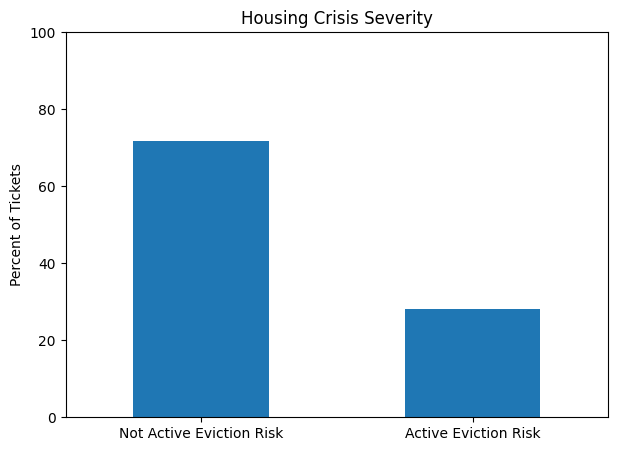

In [137]:
# Plot the overall housing crisis classification
housing_crisis_summary["Percent"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel("Percent of Tickets")
plt.xlabel("")
plt.title("Housing Crisis Severity")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

In [138]:
# Calculate active eviction risk percentage by ZIP code
zip_risk = pd.crosstab(
    task2_profiles["Zip Code Clean"],
    task2_profiles["Housing Crisis Group"],
    normalize="index"
) * 100

zip_counts = task2_profiles["Zip Code Clean"].value_counts()

# Keep ZIP codes with at least 5 tickets
common_zips = zip_counts[zip_counts >= 5].index

zip_risk_plot = zip_risk.loc[
    zip_risk.index.isin(common_zips)
].copy()

zip_risk_plot

Housing Crisis Group,Active Eviction Risk,Not Active Eviction Risk
Zip Code Clean,,
40118,17.647059,82.352941
40202,71.428571,28.571429
40203,47.058824,52.941176
40206,66.666667,33.333333
40208,11.111111,88.888889
40210,43.750000,56.250000
40211,36.363636,63.636364
40212,53.333333,46.666667
40213,20.000000,80.000000


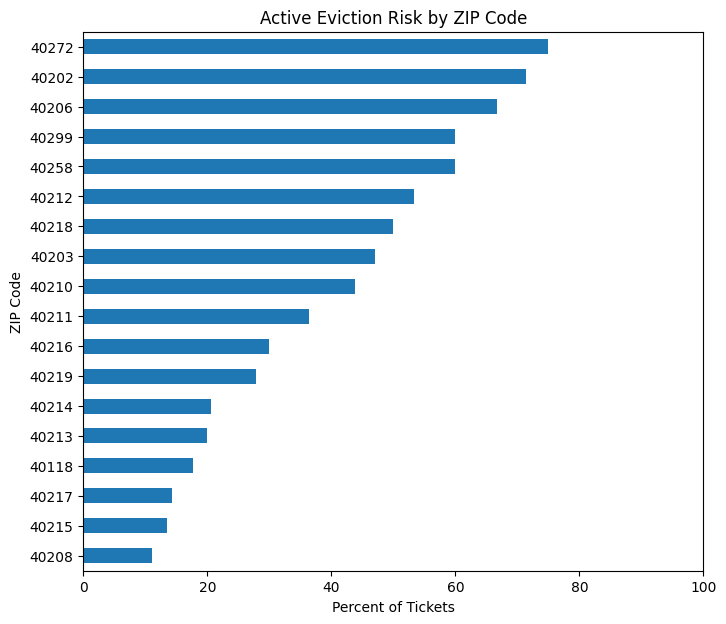

In [139]:
# Plot active eviction risk by ZIP code
zip_risk_plot["Active Eviction Risk"].sort_values().plot(
    kind="barh",
    figsize=(8, 7)
)

plt.xlabel("Percent of Tickets")
plt.ylabel("ZIP Code")
plt.title("Active Eviction Risk by ZIP Code")
plt.xlim(0, 100)
plt.show()

In [140]:
# Calculate total household size
task2_profiles["Household Size"] = (
    task2_profiles["# Additional Household Members"] + 1
)

task2_profiles["Household Size"].value_counts().sort_index()

,count
Household Size,
1,26
2,141
3,85
4,90
5,46
6,20
7,5
8,6
9,7


In [141]:
# Calculate active eviction risk percentage by household size
household_risk = pd.crosstab(
    task2_profiles["Household Size"],
    task2_profiles["Housing Crisis Group"],
    normalize="index"
) * 100

household_risk

Housing Crisis Group,Active Eviction Risk,Not Active Eviction Risk
Household Size,,
1,19.230769,80.769231
2,26.241135,73.758865
3,30.588235,69.411765
4,27.777778,72.222222
5,36.956522,63.043478
6,15.000000,85.000000
7,60.000000,40.000000
8,33.333333,66.666667
9,28.571429,71.428571


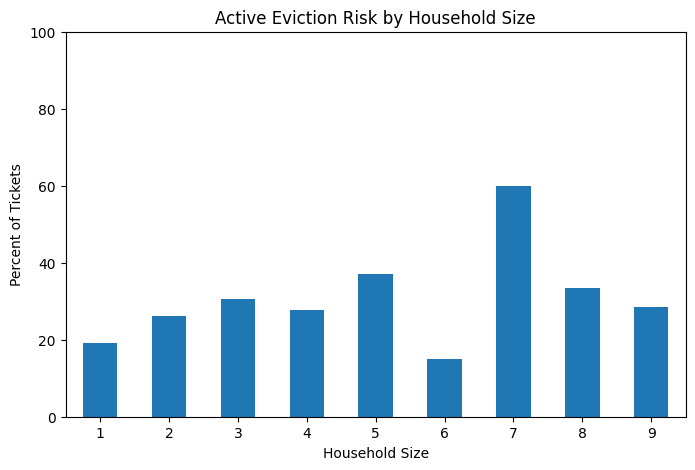

In [142]:
# Plot active eviction risk by household size
household_risk["Active Eviction Risk"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Household Size")
plt.ylabel("Percent of Tickets")
plt.title("Active Eviction Risk by Household Size")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

In [143]:
# Count the number of profile tickets for each household size
task2_profiles["Household Size"].value_counts().sort_index()

,count
Household Size,
1,26
2,141
3,85
4,90
5,46
6,20
7,5
8,6
9,7


### Question 1 — Housing Crisis Severity

For this analysis, a profile-level ticket was classified as **Active Eviction Risk** if the household was either:

- `Currently being evicted`, or
- `Unhoused`.

All other profile-level tickets were classified as **Not Active Eviction Risk**. This second category does not necessarily mean that the household was completely housing stable; it only means that the ticket did not meet the project's definition of active eviction risk.

### Overall Result

Among the 426 profile-level intake tickets:

- **120 tickets (28.17%)** showed Active Eviction Risk.
- **306 tickets (71.83%)** did not show Active Eviction Risk.

This means that a little more than one-quarter of the profile-level intake tickets represented households experiencing the most immediate forms of housing instability defined in this project.

### Differences by ZIP Code

Active eviction risk varied substantially across ZIP codes.

Among ZIP codes with at least five profile tickets, some of the highest observed active-risk percentages were:

- `40272`: **75.00%**
- `40202`: **71.43%**
- `40206`: **66.67%**
- `40258`: **60.00%**
- `40299`: **60.00%**

Some of the lowest observed percentages were:

- `40208`: **11.11%**
- `40215`: **13.48%**
- `40217`: **14.29%**
- `40118`: **17.65%**
- `40213`: **20.00%**

These results suggest that active eviction risk is not distributed evenly across the ZIP codes represented in the data.

However, several of the ZIP codes with very high percentages had relatively few tickets. For example, ZIP code `40272` had 8 tickets, `40202` had 7, and `40206` had 6. These percentages should therefore be interpreted more cautiously than percentages from ZIP codes with larger numbers of observations.

### Differences by Household Size

Active eviction risk also varied by household size:

- Household size 1: **19.23%** active risk (26 tickets)
- Household size 2: **26.24%** active risk (141 tickets)
- Household size 3: **30.59%** active risk (85 tickets)
- Household size 4: **27.78%** active risk (90 tickets)
- Household size 5: **36.96%** active risk (46 tickets)
- Household size 6: **15.00%** active risk (20 tickets)
- Household size 7: **60.00%** active risk (5 tickets)
- Household size 8: **33.33%** active risk (6 tickets)
- Household size 9: **28.57%** active risk (7 tickets)

There is no clear pattern showing that active eviction risk consistently increases or decreases as household size increases. Although household size 7 had the highest percentage, this group contained only 5 tickets, so the result should be interpreted cautiously.

### Caveats

The **Not Active Eviction Risk** category should not be interpreted as meaning that a household had no housing problems. A household could still have past-due rent, be staying with friends or family, or experience another form of housing instability without being currently evicted or unhoused.

ZIP codes with fewer than five tickets were excluded from the ZIP-code comparison because percentages based on extremely small groups could be misleading.

Both ZIP-code and household-size groups contain different numbers of observations. High or low percentages based on small groups may therefore be less reliable than percentages based on larger groups.

### Conclusion

Overall, **28.17% of profile-level intake tickets showed active eviction risk**. The percentage differed considerably across ZIP codes, while household size showed variation without a clear increasing or decreasing pattern.

## Question 2 — Employment vs. Income Mismatch

This analysis compares income amount and income source between employed and unemployed households.

The original Employment Status variable contains several categories. For this comparison:

- `Employed` and `Employed, but need more hours and/or different work` are grouped as **Employed**.
- `Unemployed but want to find work` and `Unemployed and not looking for work` are grouped as **Unemployed**.
- `Other` is excluded from the employed-versus-unemployed comparison because it cannot be clearly assigned to either group.

The cleaned income variable is used so that the previously identified unusually high and inconsistent income values do not distort the analysis.

In [144]:
# Create a simplified employed vs. unemployed variable
task2_profiles["Employment Group"] = task2_profiles[
    "Custom field (Employment Status)"
].map({
    "Employed": "Employed",
    "Employed, but need more hours and/or different work": "Employed",
    "Unemployed but want to find work": "Unemployed",
    "Unemployed and not looking for work": "Unemployed"
})

In [145]:
# Count households in each employment group
task2_profiles["Employment Group"].value_counts(dropna=False)

,count
Employment Group,
Unemployed,222
Employed,175
NaN,29


In [146]:
# Summarize cleaned income by employment group
income_by_employment = (
    task2_profiles
    .dropna(subset=["Employment Group", "Income Amount Clean"])
    .groupby("Employment Group")["Income Amount Clean"]
    .agg(["count", "mean", "median", "min", "max"])
)

income_by_employment

,count,mean,median,min,max
Employment Group,,,,,
Employed,170,1976.016941,2000.0,0.0,9000.0
Unemployed,221,517.115928,0.0,0.0,5600.0


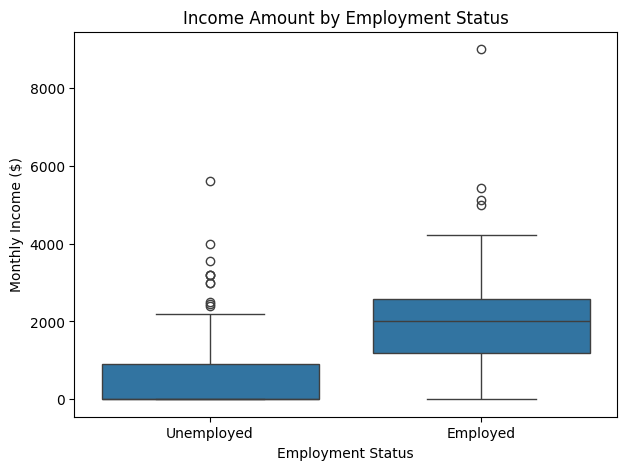

In [147]:
# Plot cleaned income amounts for employed and unemployed households
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=task2_profiles,
    x="Employment Group",
    y="Income Amount Clean"
)

plt.xlabel("Employment Status")
plt.ylabel("Monthly Income ($)")
plt.title("Income Amount by Employment Status")
plt.show()

In [148]:
# Review primary income sources
task2_profiles[
    "Custom field (Source of income)"
].value_counts(dropna=False)

,count
Custom field (Source of income),
Food benefits - TANF/SNAP,178
Full-time employment,86
No income,79
Part-time employment,38
Social Security - SSI/SSDI,22
Other,16
NaN,4
Pension,2
Veterans benefits,1


In [149]:
# Review additional income sources
task2_profiles[
    "Custom field (Source of income).1"
].value_counts(dropna=False)

,count
Custom field (Source of income).1,
NaN,268
No income,50
Part-time employment,35
Full-time employment,26
Social Security - SSI/SSDI,24
Other,19
Unemployment benefits,2
Spousal support (Alimony),1
Pension,1


In [150]:
# Combine the two income-source fields for employed and unemployed households
income_sources = task2_profiles[
    [
        "Employment Group",
        "Custom field (Source of income)",
        "Custom field (Source of income).1"
    ]
].copy()

income_sources = income_sources.melt(
    id_vars="Employment Group",
    value_vars=[
        "Custom field (Source of income)",
        "Custom field (Source of income).1"
    ],
    value_name="Income Source"
)

income_sources = income_sources.dropna(
    subset=["Employment Group", "Income Source"]
)

income_sources.head()

,Employment Group,variable,Income Source
0,Unemployed,Custom field (Source of income),Food benefits - TANF/SNAP
1,Unemployed,Custom field (Source of income),No income
2,Employed,Custom field (Source of income),Food benefits - TANF/SNAP
3,Unemployed,Custom field (Source of income),Social Security - SSI/SSDI
4,Employed,Custom field (Source of income),Part-time employment


In [151]:
# Count income sources within each employment group
income_source_counts = pd.crosstab(
    income_sources["Income Source"],
    income_sources["Employment Group"]
)

income_source_counts

Employment Group,Employed,Unemployed
Income Source,,
Food benefits - TANF/SNAP,54,111
Full-time employment,96,14
No income,3,118
Other,13,18
Part-time employment,65,6
Pension,0,2
Social Security - SSI/SSDI,5,32
Spousal support (Alimony),0,1
Unemployment benefits,0,2


In [152]:
# Calculate the percentage of reported income sources within each employment group
income_source_percent = (
    income_source_counts /
    income_source_counts.sum(axis=0) * 100
)

income_source_percent

Employment Group,Employed,Unemployed
Income Source,,
Food benefits - TANF/SNAP,22.881356,36.513158
Full-time employment,40.677966,4.605263
No income,1.271186,38.815789
Other,5.508475,5.921053
Part-time employment,27.542373,1.973684
Pension,0.000000,0.657895
Social Security - SSI/SSDI,2.118644,10.526316
Spousal support (Alimony),0.000000,0.328947
Unemployment benefits,0.000000,0.657895


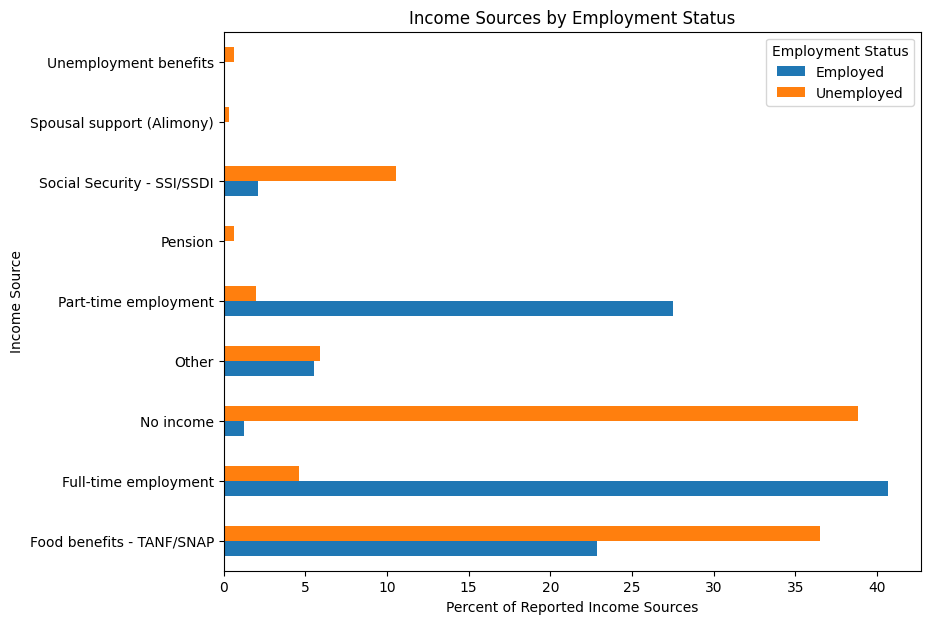

In [154]:
# Plot income sources by employment group
income_source_percent.plot(
    kind="barh",
    figsize=(9, 7)
)

plt.xlabel("Percent of Reported Income Sources")
plt.ylabel("Income Source")
plt.title("Income Sources by Employment Status")
plt.legend(title="Employment Status")
plt.show()

### Question 2 — Employment vs. Income Mismatch

For this analysis, the original employment categories were simplified into two groups:

- **Employed:** `Employed` and `Employed, but need more hours and/or different work`
- **Unemployed:** `Unemployed but want to find work` and `Unemployed and not looking for work`

The `Other` employment category was excluded because it could not be clearly classified as employed or unemployed.

The cleaned income variable was used so that the previously identified unusually high and inconsistent income values would not distort the comparison.

### Income Amount

The employed and unemployed groups showed a large difference in reported monthly income.

Among records with usable cleaned income values:

- **Employed:** 170 records
  - Mean income: **$1,976.02**
  - Median income: **$2,000**
  - Range: **$0 to $9,000**

- **Unemployed:** 221 records
  - Mean income: **$517.12**
  - Median income: **$0**
  - Range: **$0 to $5,600**

As expected, employed households generally reported higher income. However, employment status did not completely determine income. Some employed households reported very low or even zero income, while some unemployed households still reported income.

This shows that employment status alone does not fully describe the household's financial situation.

### Source of Income

Income sources also differed substantially between the two employment groups.

Among reported income sources for employed households:

- **40.68%** were Full-time employment
- **27.54%** were Part-time employment
- **22.88%** were Food benefits - TANF/SNAP
- **5.51%** were Other
- **2.12%** were Social Security - SSI/SSDI
- **1.27%** were No income

Although employment income was the most common source for employed households, almost one-quarter of reported sources were Food benefits - TANF/SNAP. This shows that being employed does not necessarily mean that a household does not rely on additional financial assistance.

Among reported income sources for unemployed households:

- **38.82%** were No income
- **36.51%** were Food benefits - TANF/SNAP
- **10.53%** were Social Security - SSI/SSDI
- **5.92%** were Other
- **4.61%** were Full-time employment
- **1.97%** were Part-time employment

The unemployed group relied much more heavily on no income, food benefits, and Social Security. However, some unemployed records also contained full-time or part-time employment as an income source. This mismatch may reflect changes in employment over time, multiple sources of household income, or inconsistencies in how the fields were recorded.

### Caveats

The income-source percentages represent **reported income sources**, not percentages of households. A household may report more than one income source because the dataset contains both a primary and secondary income-source field.

The employment grouping also simplifies the original categories. For example, people who were employed but needed more hours or different work were grouped with other employed households even though they may still be experiencing significant financial hardship.

The cleaned income analysis excluded six unusually high values that appeared inconsistent with the monthly scale used by the Income Amount field.

Finally, the data contains profile-level tickets rather than one unique observation per household, so the same PID may appear on more than one profile ticket.

### Conclusion

Employment status is related to income, but it does not fully explain financial hardship in this population. Employed households had much higher median income than unemployed households, but some employed households still reported little or no income and many relied on food benefits. At the same time, unemployed households could still receive income from Social Security, employment, or other sources.

The results show why both **income amount and income source** are needed in addition to employment status when describing a household's financial situation.

## Question 3 — Household Composition

This analysis describes what a typical household looks like in the dataset by examining:

- total household size,
- number of children age 17 and under,
- and the ages of additional household members.

The intake dataset is used for overall household size and the recorded number of children. The `household_members_long_v2.csv` file is used to describe the ages of the additional family members so that the analysis is not limited to the primary contact.

In [155]:
# Create a cleaned age variable for additional household members
task2_household["Age Clean"] = task2_household["Age"].copy()

task2_household.loc[
    (task2_household["Age Clean"] < 0) |
    (task2_household["Age Clean"] > 120),
    "Age Clean"
] = np.nan

In [156]:
# Summarize cleaned ages of additional household members
task2_household["Age Clean"].describe()

,Age Clean
count,891.000000
mean,9.373737
std,10.588554
min,0.000000
25%,3.000000
50%,6.000000
75%,12.000000
max,72.000000


In [157]:
# Count missing ages after cleaning
task2_household["Age Clean"].isnull().sum()

np.int64(102)

In [158]:
# Summarize total household size
task2_profiles["Household Size"].describe()

,Household Size
count,426.000000
mean,3.330986
std,1.633712
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,9.000000


In [159]:
# Find the typical household size
print("Median household size:", task2_profiles["Household Size"].median())
print("Most common household size:", task2_profiles["Household Size"].mode()[0])

Median household size: 3.0
Most common household size: 2


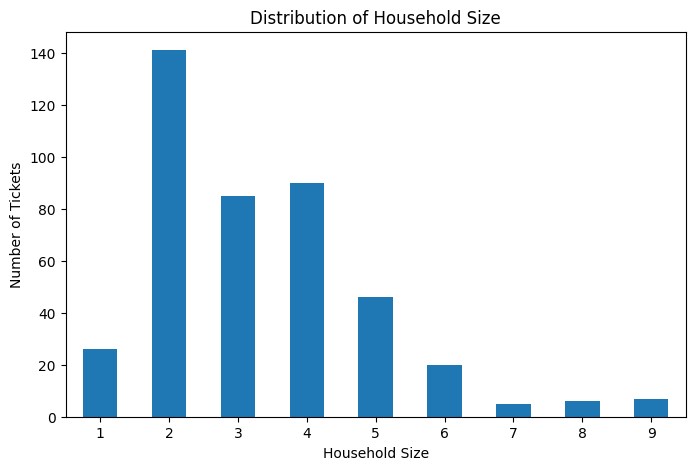

In [160]:
# Plot the distribution of household size
task2_profiles["Household Size"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Household Size")
plt.ylabel("Number of Tickets")
plt.title("Distribution of Household Size")
plt.xticks(rotation=0)
plt.show()

In [161]:
# Count the recorded number of children in each household
children_counts = task2_profiles[
    "Custom field (People in Household 17 and Under)"
].value_counts()

children_counts

,count
Custom field (People in Household 17 and Under),
2,128
1,103
3,98
4,41
0,27
More than 5,15
5,14


In [162]:
# Order the child-count categories for analysis
children_order = [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "More than 5"
]

children_counts = task2_profiles[
    "Custom field (People in Household 17 and Under)"
].value_counts().reindex(children_order)

children_counts

,count
Custom field (People in Household 17 and Under),
0,27
1,103
2,128
3,98
4,41
5,14
More than 5,15


In [163]:
# Find the most common recorded number of children
task2_profiles[
    "Custom field (People in Household 17 and Under)"
].mode()[0]

'2'

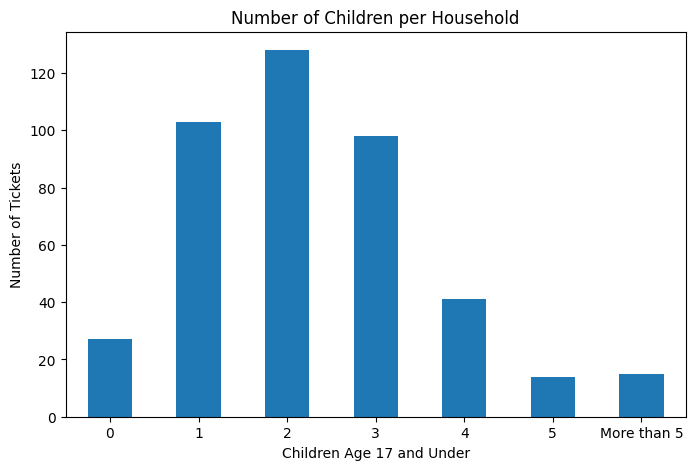

In [164]:
# Plot the distribution of children age 17 and under
children_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Children Age 17 and Under")
plt.ylabel("Number of Tickets")
plt.title("Number of Children per Household")
plt.xticks(rotation=0)
plt.show()

In [165]:
# Summarize the ages of additional household members
task2_household["Age Clean"].describe()

,Age Clean
count,891.000000
mean,9.373737
std,10.588554
min,0.000000
25%,3.000000
50%,6.000000
75%,12.000000
max,72.000000


In [166]:
# Find the median age of additional household members
print(
    "Median age of additional household members:",
    task2_household["Age Clean"].median()
)

Median age of additional household members: 6.0


In [167]:
# Count children and adults among additional household members with known ages
additional_age_groups = pd.Series({
    "Children (0-17)": (
        task2_household["Age Clean"].between(0, 17)
    ).sum(),

    "Adults (18+)": (
        task2_household["Age Clean"] >= 18
    ).sum()
})

additional_age_groups

,0
Children (0-17),763
Adults (18+),128


In [168]:
# Calculate age-group percentages among additional household members
additional_age_percent = (
    additional_age_groups /
    additional_age_groups.sum() * 100
)

additional_age_percent

,0
Children (0-17),85.634119
Adults (18+),14.365881


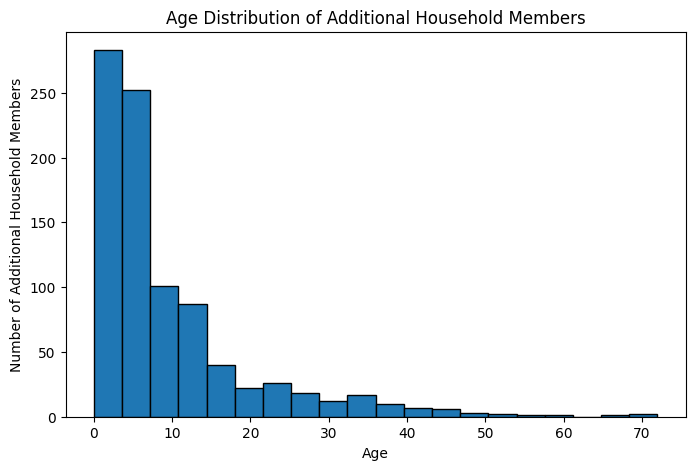

In [169]:
# Plot ages of additional household members
plt.figure(figsize=(8, 5))

plt.hist(
    task2_household["Age Clean"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.xlabel("Age")
plt.ylabel("Number of Additional Household Members")
plt.title("Age Distribution of Additional Household Members")
plt.show()

### Question 3 — Household Composition

To describe the typical household, the intake dataset was used for overall household size and the reported number of children, while `household_members_long_v2.csv` was used to examine the ages of additional family members.

### Household Size

Among the 426 profile-level intake tickets, household size ranged from **1 to 9 people**.

- Mean household size: **3.33 people**
- Median household size: **3 people**
- Most common household size: **2 people**
- 25% of households had 2 or fewer people
- 75% of households had 4 or fewer people

This suggests that a typical household in the dataset contains approximately **2 to 4 people**, with a median household size of 3.

### Number of Children

The reported number of household members age 17 and under was:

- 0 children: **27 households**
- 1 child: **103 households**
- 2 children: **128 households**
- 3 children: **98 households**
- 4 children: **41 households**
- 5 children: **14 households**
- More than 5 children: **15 households**

The most common response was **2 children**, reported by 128 households. Most households therefore included multiple children, which is consistent with the young-family population represented in the dataset.

### Ages of Additional Household Members

The household-member file was used to examine the ages of additional household members rather than only the primary contact.

After removing clearly invalid ages, **891 additional household members** had usable age information.

Their ages ranged from **0 to 72 years**, with:

- Mean age: **9.37 years**
- Median age: **6 years**
- 25th percentile: **3 years**
- 75th percentile: **12 years**

The additional household members were strongly concentrated among children:

- **763 members (85.63%)** were age 0–17
- **128 members (14.37%)** were age 18 or older

This indicates that the additional household members in the dataset are predominantly children, and many are very young.

### Caveats

The household-size measure was calculated as the primary contact plus the number of additional household members recorded on the profile ticket.

The variable for children age 17 and under includes the category `More than 5`, so an exact average number of children cannot be calculated without making an unsupported assumption about those households.

The age analysis uses only the additional household members in `household_members_long_v2.csv`. It does not include the age of the primary contact.

Some household-member ages were missing or invalid. Clearly impossible ages were treated as missing rather than estimated, so the age analysis is based on the 891 members with usable age values.

### Conclusion

The typical household in this dataset contains approximately **3 people** and commonly includes **2 children**. Additional household members are overwhelmingly young: the median age is only **6 years**, and approximately **85.6%** of additional household members with known ages are children.

Overall, the data describes a population composed primarily of relatively small households with young children.

## Question 4 — Repeat Contact

Repeat contact is measured using `PID`, which identifies the same person across multiple tickets.

First, all intake tickets are used to determine how many PIDs appear on more than one ticket.

For the housing and eviction comparison, only profile-level tickets are used because service and care-path subtickets generally do not contain Housing Status or Eviction Status. For repeat-contact PIDs with at least two profile records, the first profile record is compared with the most recent profile record.

In [170]:
# Count the number of tickets for each PID
pid_ticket_counts = (
    task2_intakes["PID"]
    .value_counts()
    .sort_index()
)

pid_ticket_counts.describe()

,count
count,439.000000
mean,1.455581
std,0.729176
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,6.000000


In [171]:
# Summarize one-time and repeat-contact PIDs
repeat_contact_summary = pd.Series({
    "One Ticket": (pid_ticket_counts == 1).sum(),
    "More Than One Ticket": (pid_ticket_counts > 1).sum()
})

repeat_contact_summary

,0
One Ticket,289
More Than One Ticket,150


In [172]:
# Calculate percentages for one-time and repeat-contact PIDs
repeat_contact_percent = (
    repeat_contact_summary /
    repeat_contact_summary.sum() * 100
)

repeat_contact_percent

,0
One Ticket,65.831435
More Than One Ticket,34.168565


In [173]:
# Show how many people had 1, 2, 3, or more tickets
ticket_distribution = (
    pid_ticket_counts
    .value_counts()
    .sort_index()
    .rename_axis("Tickets per PID")
    .to_frame("Number of People")
)

ticket_distribution

,Number of People
Tickets per PID,
1,289
2,109
3,34
4,6
6,1


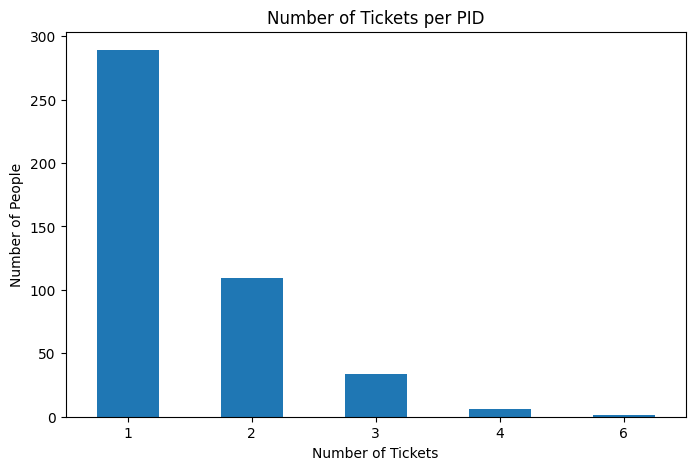

In [174]:
# Plot the distribution of tickets per PID
ticket_distribution["Number of People"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Number of Tickets")
plt.ylabel("Number of People")
plt.title("Number of Tickets per PID")
plt.xticks(rotation=0)
plt.show()

In [175]:
# Identify PIDs that appear on two or more tickets
repeat_pids = pid_ticket_counts[
    pid_ticket_counts >= 2
].index

len(repeat_pids)

150

In [176]:
# Keep profile records belonging to repeat-contact PIDs
repeat_profiles = task2_profiles[
    task2_profiles["PID"].isin(repeat_pids)
].copy()

repeat_profiles["Created"] = pd.to_datetime(
    repeat_profiles["Created"],
    errors="coerce"
)

In [177]:
# Count profile records for each repeat-contact PID
repeat_profile_counts = (
    repeat_profiles["PID"]
    .value_counts()
)

print(
    "Repeat-contact PIDs:",
    len(repeat_pids)
)

print(
    "Repeat PIDs with at least 2 profile records:",
    (repeat_profile_counts >= 2).sum()
)

print(
    "Repeat PIDs with fewer than 2 profile records:",
    len(repeat_pids) - (repeat_profile_counts >= 2).sum()
)

Repeat-contact PIDs: 150
Repeat PIDs with at least 2 profile records: 27
Repeat PIDs with fewer than 2 profile records: 123


In [178]:
# Keep repeat PIDs with at least two profile records
comparable_pids = repeat_profile_counts[
    repeat_profile_counts >= 2
].index

comparison_profiles = repeat_profiles[
    repeat_profiles["PID"].isin(comparable_pids)
].sort_values(
    ["PID", "Created"]
)

In [179]:
# Get the first profile record for each comparable PID
first_profiles = (
    comparison_profiles
    .drop_duplicates("PID", keep="first")
    [
        [
            "PID",
            "Custom field (Housing Status)",
            "Custom field (Eviction Status)"
        ]
    ]
    .rename(columns={
        "Custom field (Housing Status)": "First Housing Status",
        "Custom field (Eviction Status)": "First Eviction Status"
    })
)

In [180]:
# Get the most recent profile record for each comparable PID
recent_profiles = (
    comparison_profiles
    .drop_duplicates("PID", keep="last")
    [
        [
            "PID",
            "Custom field (Housing Status)",
            "Custom field (Eviction Status)"
        ]
    ]
    .rename(columns={
        "Custom field (Housing Status)": "Recent Housing Status",
        "Custom field (Eviction Status)": "Recent Eviction Status"
    })
)

In [181]:
# Combine first and most recent housing information
repeat_changes = first_profiles.merge(
    recent_profiles,
    on="PID"
)

repeat_changes.head()

,PID,First Housing Status,First Eviction Status,Recent Housing Status,Recent Eviction Status
0,P0021,Rent- past due,Unknown,Rent- past due,Currently being evicted
1,P0025,Rent- past due,Unknown,Rent- past due,Not being evicted
2,P0053,Staying with friends/family,Currently being evicted,Rent- past due,Not being evicted
3,P0072,Rent - nothing past due,Not being evicted,Rent - nothing past due,Not being evicted
4,P0076,Rent- past due,Unknown,Rent- past due,Unknown


In [182]:
# Determine whether housing or eviction status changed
repeat_changes["Housing Status Changed"] = (
    repeat_changes["First Housing Status"] !=
    repeat_changes["Recent Housing Status"]
)

repeat_changes["Eviction Status Changed"] = (
    repeat_changes["First Eviction Status"] !=
    repeat_changes["Recent Eviction Status"]
)

In [183]:
# Summarize housing and eviction status changes
change_summary = pd.DataFrame({
    "Changed": [
        repeat_changes["Housing Status Changed"].sum(),
        repeat_changes["Eviction Status Changed"].sum()
    ],
    "Unchanged": [
        (~repeat_changes["Housing Status Changed"]).sum(),
        (~repeat_changes["Eviction Status Changed"]).sum()
    ]
}, index=[
    "Housing Status",
    "Eviction Status"
])

change_summary

,Changed,Unchanged
Housing Status,5,22
Eviction Status,8,19


In [184]:
# Calculate percentage changed and unchanged
change_percent = (
    change_summary
    .div(change_summary.sum(axis=1), axis=0)
    * 100
)

change_percent

,Changed,Unchanged
Housing Status,18.518519,81.481481
Eviction Status,29.629630,70.370370


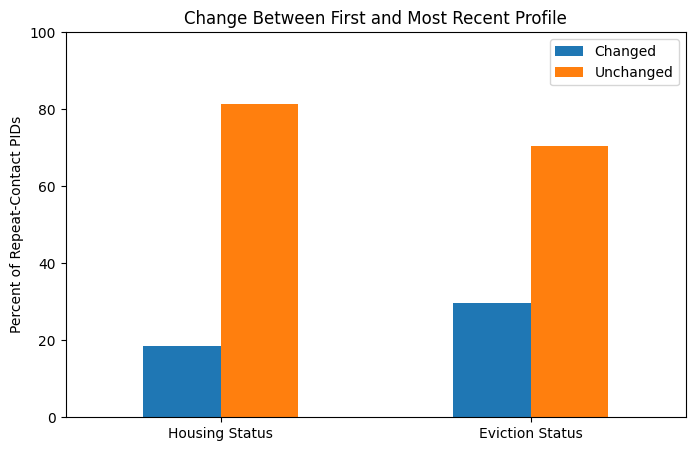

In [185]:
# Plot percentage of repeat contacts whose status changed
change_percent.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("")
plt.ylabel("Percent of Repeat-Contact PIDs")
plt.title("Change Between First and Most Recent Profile")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="")
plt.show()

In [186]:
# Show transitions in Housing Status
housing_transitions = pd.crosstab(
    repeat_changes["First Housing Status"],
    repeat_changes["Recent Housing Status"]
)

housing_transitions

Recent Housing Status,Rent - nothing past due,Rent- past due,Unhoused
First Housing Status,,,
Rent - nothing past due,7,2,0
Rent- past due,1,14,0
Staying with friends/family,1,1,0
Unhoused,0,0,1


In [187]:
# Show transitions in Eviction Status
eviction_transitions = pd.crosstab(
    repeat_changes["First Eviction Status"],
    repeat_changes["Recent Eviction Status"]
)

eviction_transitions

Recent Eviction Status,Currently being evicted,Not being evicted,Unknown
First Eviction Status,,,
Currently being evicted,3,2,0
Not being evicted,1,15,0
Unknown,2,3,1


### Question 4 — Repeat Contact

Repeat contact was measured using `PID`, which identifies the same person across multiple tickets.

All intake tickets were used to determine how many people appeared more than once. Housing and eviction changes were then examined using profile-level tickets because service and care-path subtickets generally do not contain Housing Status or Eviction Status.

### How Many People Had Repeat Contact?

There were **439 unique PIDs** in the intake dataset.

- **289 people (65.83%)** appeared on only one ticket.
- **150 people (34.17%)** appeared on more than one ticket.

The number of tickets per person was:

- 1 ticket: **289 people**
- 2 tickets: **109 people**
- 3 tickets: **34 people**
- 4 tickets: **6 people**
- 6 tickets: **1 person**

Therefore, approximately one-third of the people represented in the dataset had more than one recorded contact.

### First vs. Most Recent Profile

Although 150 PIDs appeared on more than one ticket, many of those additional tickets were service or care-path subtickets rather than new profile records.

Only **27 repeat-contact PIDs** had at least two profile-level records that could be used to compare Housing Status and Eviction Status between their first and most recent profiles.

### Housing Status Changes

Among the 27 comparable repeat-contact PIDs:

- **5 people (18.52%)** had a different Housing Status on their most recent profile.
- **22 people (81.48%)** had the same Housing Status.

Most people therefore had no recorded change in Housing Status between their first and most recent profiles.

Examples of observed changes included:

- 2 people moved from `Rent - nothing past due` to `Rent- past due`.
- 1 person moved from `Rent- past due` to `Rent - nothing past due`.
- 1 person moved from `Staying with friends/family` to `Rent - nothing past due`.
- 1 person moved from `Staying with friends/family` to `Rent- past due`.

### Eviction Status Changes

Eviction Status changed more often than Housing Status.

Among the 27 comparable PIDs:

- **8 people (29.63%)** had a different Eviction Status.
- **19 people (70.37%)** had no change.

The observed transitions included:

- 2 people moved from `Currently being evicted` to `Not being evicted`.
- 1 person moved from `Not being evicted` to `Currently being evicted`.
- 2 people moved from `Unknown` to `Currently being evicted`.
- 3 people moved from `Unknown` to `Not being evicted`.

This shows that some repeat contacts experienced meaningful changes in their housing situation, although most remained in the same recorded category.

### Caveats

The main limitation is that repeat contact does not always mean that a person completed another full intake. Many repeat PIDs had additional service or care-path subtickets that did not contain Housing Status or Eviction Status.

As a result, although 150 people had more than one ticket, only 27 had at least two profile-level records that could be compared over time.

The analysis also shows whether a category changed, but a change is not always clearly an improvement or deterioration. For example, moving from `Unknown` eviction status to another category may simply represent better information being collected during the later intake.

Finally, PID matching is based on person matching and may not be perfectly reliable, so repeat-contact results should be interpreted as an estimate based on the available identifiers.

### Conclusion

Repeat contact was common in the dataset: **34.17% of unique PIDs appeared on more than one ticket**.

Among repeat-contact PIDs with enough profile data to compare over time, most remained in the same recorded housing and eviction categories. **18.52% changed Housing Status**, while **29.63% changed Eviction Status**.

The results suggest that repeat interaction with SLCM does sometimes coincide with changes in housing circumstances, but the limited number of repeat profile records makes it difficult to determine a consistent direction of change.

## Question 5 — Data Quality

Several data-quality problems were identified during the exploratory analysis. The two most important issues were impossible age values in the household-member file and unrealistic or inconsistent monetary values in the intake data.

### Issue 1 — Invalid Household Member Ages

The `Age` variable in `household_members_long_v2.csv` contained values that were not possible human ages. The original data included ages below 0 and extremely large values, with values ranging from approximately -35 to 1,824.

There were originally 900 non-missing age values. After identifying ages below 0 or above 120 as invalid, 9 values were treated as missing. This left **891 usable age values** for the household-member analysis.

The invalid ages were not replaced with estimated values because there was no reliable way to determine the intended ages. Instead, a new variable called `Age Clean` was created, and impossible values were replaced with `NaN`.

This prevents invalid ages from affecting averages, medians, age distributions, and the child-versus-adult analysis while preserving the original Age variable for reference.

### Issue 2 — Incorrect and Inconsistent Monetary Values

Several monetary variables contained values that were inconsistent with the scale and meaning of the fields.

The most obvious examples were:

- Monthly Rent: **$125,100**
- Past Due Rent: **$242,682**

These values were considered clear data-entry errors. Because the correct amounts could not be determined, they were replaced with `NaN` rather than being guessed.

After cleaning:

- Maximum Monthly Rent became **$3,743.94**
- Maximum Past Due Rent became **$16,000**

The Income Amount variable also contained six unusually high values ranging from **$24,000 to $75,000**.

The recorded Rent-to-Income percentage showed that Income Amount was normally being treated as a **monthly income** variable. For example, a monthly rent of $1,200 and an income of $2,500 produced a recorded Rent-to-Income value of 48%, matching:

$1,200 / $2,500 \times 100 = 48\%$

Because the unusually high income values were inconsistent with this monthly scale, a cleaned income variable was created. Income values greater than $10,000 were treated as missing for numerical analysis.

These values were not divided by 12 because there was not enough evidence to know whether they represented annual salary, misplaced digits, or another type of entry error.

### Additional Issue — Geographic Formatting

The geographic variables also contained inconsistent formatting.

Examples included:

- ZIP+4 values mixed with five-digit ZIP codes
- one invalid ZIP code: `402q1`
- multiple spellings of Louisville such as `Lousville`, `Louisvile`, and `Louisvlle`
- both `KY` and `KENTUCKY` used for the same state

Cleaned ZIP, City, and State variables were created. Clear spelling and formatting inconsistencies were standardized, while values that could not be reliably corrected were treated as missing.

### Why These Decisions Were Made

The cleaning process was intentionally conservative. Clear errors were corrected or treated as missing, but values were not estimated when the correct value could not be determined.

Replacing questionable values with guessed values could introduce additional errors into the analysis. Preserving the original variables and creating cleaned versions also makes the cleaning process transparent and reproducible.

### Caveats

Some values that appear unusual may still be valid. For this reason, values were not removed simply because they were large. For example, a Past Due Rent value of $16,000 was retained because it could represent several months of unpaid rent.

Similarly, missing values were generally not replaced with zeros because missing information and a true value of zero have different meanings.

### Conclusion

The data contained several important quality issues, especially impossible ages and inconsistent monetary values. Cleaning these problems was necessary because they could substantially distort summary statistics and plots.

Rather than guessing the intended values, invalid or ambiguous entries were generally treated as missing. This provides a more reliable dataset while preserving as much of the original information as possible.

In [189]:
# Display invalid ages from the original household dataset
invalid_ages = household[
    (household["Age"] < 0) |
    (household["Age"] > 120)
]

invalid_ages[
    ["PID", "Member ID", "Issue key", "Age"]
]

,PID,Member ID,Issue key,Age
79,P0365,P0365-M4,NEIG-18928,-1.0
106,P0237,P0237-M1,NEIG-18625,-1.0
231,P0301,P0301-M2,NEIG-17437,-35.0
600,P0321,P0321-M1,NEIG-14523,1823.0
745,P0214,P0214-M1,NEIG-13236,-9.0
793,P0115,P0115-M1,NEIG-12698,1824.0
944,P0256,P0256-M1,NEIG-11303,1824.0
959,P0224,P0224-M1,NEIG-11138,-1.0
970,P0084,P0084-M1,NEIG-10903,1806.0


In [190]:
# Count invalid ages in the original household dataset
print("Invalid ages:", len(invalid_ages))

Invalid ages: 9


In [191]:
# Compare original and cleaned age information
print("Original non-missing ages:", household["Age"].notna().sum())

print(
    "Original invalid ages:",
    ((household["Age"] < 0) | (household["Age"] > 120)).sum()
)

print(
    "Cleaned usable ages:",
    task2_household["Age Clean"].notna().sum()
)

Original non-missing ages: 900
Original invalid ages: 9
Cleaned usable ages: 891


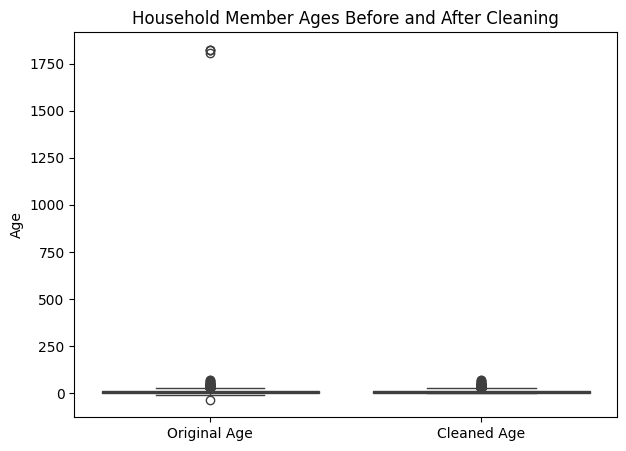

In [192]:
# Compare household-member ages before and after cleaning
age_comparison = pd.DataFrame({
    "Original Age": household["Age"],
    "Cleaned Age": task2_household["Age Clean"]
})

plt.figure(figsize=(7, 5))

sns.boxplot(data=age_comparison)

plt.ylabel("Age")
plt.title("Household Member Ages Before and After Cleaning")
plt.show()

In [193]:
# Keep original profile records for comparison
original_profiles = task2_intakes[
    task2_intakes["Issue Type"].isin(profile_types)
].copy()

In [194]:
# Compare monetary values before and after cleaning
money_cleaning_summary = pd.DataFrame({
    "Variable": [
        "Monthly Rent",
        "Past Due Rent"
    ],
    "Original Maximum": [
        original_profiles["Custom field (Monthly Rent ($))"].max(),
        original_profiles["Custom field (Past Due Rent ($))"].max()
    ],
    "Cleaned Maximum": [
        task2_profiles["Custom field (Monthly Rent ($))"].max(),
        task2_profiles["Custom field (Past Due Rent ($))"].max()
    ]
})

money_cleaning_summary

,Variable,Original Maximum,Cleaned Maximum
0,Monthly Rent,125100.0,3743.94
1,Past Due Rent,242682.0,16000.00


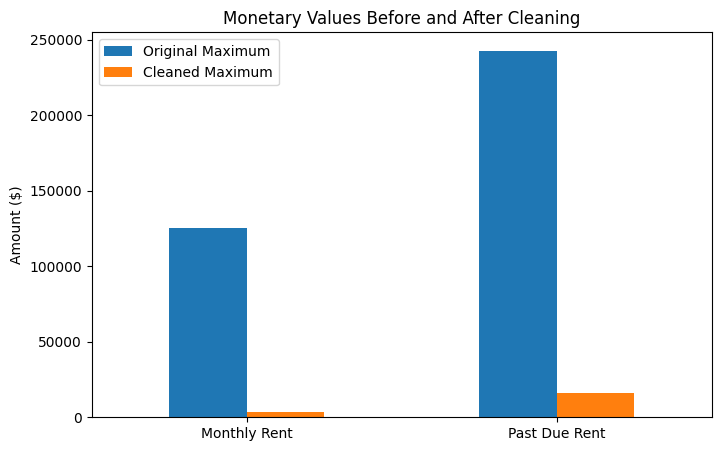

In [195]:
# Plot maximum monetary values before and after cleaning
money_cleaning_summary.set_index("Variable")[
    ["Original Maximum", "Cleaned Maximum"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Amount ($)")
plt.xlabel("")
plt.title("Monetary Values Before and After Cleaning")
plt.xticks(rotation=0)
plt.show()